<a href="https://colab.research.google.com/github/koffifidelek59-collab/agricultural-monitoring-ftw/blob/main/Predicting_Mobility_Demand_From_Urban_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# MIT License
#
#@title Copyright (c) 2026 CCAI Community Authors { display-mode: "form" }
#
# Permission is hereby granted, free of charge, to any person obtaining a
# copy of this software and associated documentation files (the "Software"),
# to deal in the Software without restriction, including without limitation
# the rights to use, copy, modify, merge, publish, distribute, sublicense,
# and/or sell copies of the Software, and to permit persons to whom the
# Software is furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL
# THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING
# FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER
# DEALINGS IN THE SOFTWARE.

# Predicting Mobility Demand From Urban Features

Authors:
*   Konstantin Klemmer, Microsoft Research & CCAI, konstantin@climatechange.ai
*   Shafat Rahman, CCAI, shafatrahman@climatechange.ai
*   Felix Wagner, TU Berlin & Mercator Research Institute on Global Commons and Climate Change, wagner@mcc-berlin.net
*   Florian Nachtigall, TU Berlin & Mercator Research Institute on Global Commons and Climate Change, nachtigall@tu-berlin.de
*   Gabriela Yaulli Herrera, Cornell Tech, cgy4@cornell.edu

## Learning Objectives

By the end of this tutorial, you will be able to:
* Explain how urban points-of-interest (POI) data can be used to model shared-bike demand, and why this matters for climate-friendly transport planning
* Build and compare three models (linear regression, gradient boosting, GNN) for a spatial prediction task, and evaluate them on unseen data
* Identify signs of over/underfitting and apply basic mitigation strategies
* Describe the key risks of applying a model like this one in a *different* city than the one it was trained on
* Discuss who would use this kind of model in practice, and what validation/governance should happen before its outputs inform real infrastructure decisions

**Prerequisites:** basic Python, pandas, and familiarity with linear regression. No prior GNN experience is required — the tutorial explains this as it goes.

# Table of Contents


*   [Overview](#overview)
*   [Climate Impact](#climate-impact)
*   [Background & Prerequisites](#background-and-prereqs)
*   [Software Requirements](#software-requirements)
*   [Data Description](#data-description)
*   [Methodology](#methodology)
    *   [Linear Regression](#lr)
    *   [Gradient Boosting Decision Trees](#gbdt)
    *   [Graph Neural Network (GNN)](#gnn)
*   [Results](#results)
*   [Discussion](#discussion)
    *   [Take-aways](#take-aways)
    *   [Limitations](#limitations)
    *   [Explainability](#explainability)
    *   [Deriving Policy Advice](#policy-advice)
    *   [Next Steps](#next-steps)
*   [References](#references)


---
### 📌 Submission note

**Author of this submission:** Fidèle Koffi KOUAME, WASCAL IMP-EGH (Energy and Green
Hydrogen Technology, System Analysis), Abdou Moumouni University, Niamey.
**Tutorial:** Klemmer, Rahman, Wagner, Nachtigall & Yaulli Herrera (2026),
*Predicting Mobility Demand From Urban Features*. MIT License.

All four exercises are completed, plus the written reflection. The tutorial's
own cells, including its reference solutions, are unchanged. My work sits in
the exercise cells and in the markdown cells marked **✍️**.

| Exercise | What I added beyond the reference solution |
|---|---|
| 1. XGBoost | The fill, plus why this in-sample R-squared is not a model comparison |
| 2. Tune the GNN | Standardised inputs and target, early stopping with a patience set to the noise of the validation curve, and a sweep over three graph layer types |
| 3. XGBoost search | A corrected search space, sixty draws instead of five, and the same search repeated under **spatially blocked** cross-validation to quantify how much the standard number is inflated |
| 4. Policy advice | An out-of-distribution check on the candidate cells and an ensemble spread, so the shortlist carries its own uncertainty |
| Reflection | Applying the trained model to Niamey, and why the method transfers while the model does not |

One argument runs through exercises 2, 3 and 4. The notebook splits
spatially autocorrelated hexagons at random, so neighbouring cells land on both
sides of every split. The tutorial's own Limitations section is about spatial
generalisation, yet nothing in the evaluation measures it. Where I could
measure it cheaply I did, and I report the gap rather than the flattering
number.

---


# Exercises
1.   [Use XGBoost for prediction](#task-xgboost)
1.   [Optimize GNN hyperparameters](#"task-GNN-tune")
1.   [Optimize XGBOOST hyperparameters](#task-hyperparameters)
1.   [Policy advice: Predict optimal future bike stand location](#task-policy-advice)


<a name="overview"></a>
# Overview

In this tutorial, we investigate the relationship between urban characteristics, such as the location of different shops and services, and bike-sharing demand. From a dataset of shared bike trips in Shenzhen, we count the number of trips ending in each neighborhood in the city, and count the corresponding number of points of interest, such as medical services, transportation services, etc. Then, we apply linear regression and a graph neural network to model the relationship between POI densities and trip end densities.

Note: this tutorial is a single-city case study. The specific relationships we find between POIs and bike trips reflect Shenzhen's infrastructure, travel culture, and data collection process — later in the tutorial we discuss why these relationships may not transfer directly to other cities.

<a name="climate-impact"></a>
# Climate Impact

Studying bike-sharing data could help us determine the demand for shared bikes at different locations at different times of day and days of the week. This information can be used to make sure that enough bikes are available at bike stands during hours of peak demand, hence ensuring that commuters do not turn to less climate-friendly greenhouse gas-emitting modes of transportation because of a lack of shared bikes.

Modeling the relationship between bike usage and POIs can also inform where to set up new shared-bike stands. For example, if a lot of people prefer to bike to public transportation services, new shared-bike stands could be installed at bus and train stations that do not have shared-bike coverage.

Investigating areas with low shared-bike demand can reveal issues such as lack of bike lanes that are keeping more people from adopting greener transportation habits.

**Who would use this?** In practice, outputs like these would inform city transport planners and bike-share operators deciding where to invest in stands or bike lanes. The people most affected are residents of the areas gaining (or not gaining) new infrastructure — so an equity lens matters: a model trained mainly on existing, already-served areas can reinforce existing service gaps if applied uncritically.

<a name="background-and-prereqs"></a>
# Background & Prerequisites

To get the most out of this tutorial, you should have a basic understanding of data processing and cleaning. Familiarity with handling spatial data such are latitude and longitude coordinates will be helpful.

You should also be familiar with simple modeling techniques such as linear regression.




<a name="software-requirements"></a>
# Software Requirements

Below we will import the python libraries necessary for this tutorial. Some libraries have to be installed because they are not automatically available in Colab's Python environment.

In [2]:
import os
from pathlib import Path
import shutil
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

%matplotlib inline

In [3]:
!pip install geopandas
!pip install openpyxl
!pip install h3pandas
!pip install shap
!pip install mapclassify

import openpyxl
import geopandas as gpd
import h3pandas
import shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.4 MB/s eta 0:00:00


In [4]:
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)

!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q pyg-lib -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-cluster -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git

2.11.0+cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.1/682.1 kB 13.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 21.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 34.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.0/828.0 kB 1.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [5]:
# For now, we will disable some known warnings to improve the readability of the cell outputs.
warnings.resetwarnings()
warnings.simplefilter(action='ignore', category=DeprecationWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

<a name="data-description"></a>
# Data Description

Our data include:
* Shape files specifying locations of points of interest (POI) in folder ShenzhenPOI/ShapeFile. The filenames of the shape files include the POI category.
* The shenzhenPOI folder also contains an excel file called amap_poicode.xlsx which contains translations of POI category names from Chinese to English.
* Trip data from 2021 in the folder called 8.01-8.30.
* Shape files for Shenzhen, Shenzhen's population distribution, Shenzhen's bus and metro stops


**Datasheet brief:** This trip data was collected from a commercial bike-share operator in Shenzhen over four days in July 2021, so it reflects one season, one operator, and one city's cycling culture — not a general model of cycling behavior. POI data comes from a separate mapping provider and may lag real-world changes (new businesses, closures). We also work with a random subsample of the full trip data for speed, which can slightly distort rare/localized patterns. See [Gebru et al., 2018](https://arxiv.org/abs/1803.09010) for the full datasheet framework this is based on.

## Data Download
Our data is stored in a public Google Drive folder at https://drive.google.com/drive/u/3/folders/18bdGh6IIRhqKr3gPQhbuhkOgZykBrfqx. We can download the data using gdown.

The data download and extraction below should not take more than 5 minutes.

In [6]:
!gdown --folder --remaining-ok https://drive.google.com/drive/u/3/folders/1sLp2mWlBMX3mRnkTAzHcMBStCXLK2KDN -O /content/data/

Retrieving folder contents
Retrieving folder 1OinJcYU7BfJDrzE8AlTrHtdC9GDgjrw7 8.01-8.30
Processing file 1ROAzky8XOtq40FdrvO4_4iHMIfzUw40s shared_bike_data.zip
Retrieving folder 1Urx8M4i-XurgPGW43XghYQQ-jVVuLzn7 bus_metro
Retrieving folder 1uJBsF_UvqCZaLBpzMG_wEzGKG6atnVDR bus_station_shp
Processing file 1uYb-CvKS2FkqJVnYlTqiI7Oj74vShRqM bus_station_point.cpg
Processing file 1yGA8KxI7M7WCv69qHxr08qbzmoQkxMwP bus_station_point.dbf
Processing file 1xBJT7SjjYbDfn3_zlafsBkiklgeglL6N bus_station_point.prj
Processing file 1fjo9sWAy4_6rKnThJkLFOvzJO1nUurxb bus_station_point.shp
Processing file 17CqgxB8Hw7RzjRjCfwYIbFC8mcH9c-zh bus_station_point.shx
Processing file 1Ai7IawCgQgVCdtdatBrmfS1XkDz4WOP- metro_area.csv
Retrieving folder 118YyeAwzcDbA_Zq7kjKS3jYNburXQt_G pop
Processing file 1w1dZjxoRaWDAmmB7tmG8WSDU6Rs3cqT4 pop_shenzhen.tif
Processing file 1Mbylsw2F9Thc1wQgayZgADFV2tkakeZz pop.cpg
Processing file 166jNIIRqz3CqRo4B5ZrP_E17ey__JBvt pop.dbf
Processing file 1zo2yGRzmsm82xTeqLRN_lv9FI0sAS

The trip start and end data are stored in csv files within a compressed file called shared_bike_data.zip. We start by unzipping the file.

In [7]:
!unzip '/content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data.zip' -d '/content/data/Shenzhen Bike-Share Data/8.01-8.30/'

Archive:  /content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data.zip
   creating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data/
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/__MACOSX/._shared_bike_data  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data/21_1000w.csv  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/__MACOSX/shared_bike_data/._21_1000w.csv  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data/22_1000w.csv  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/__MACOSX/shared_bike_data/._22_1000w.csv  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data/24_1000w.csv  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/__MACOSX/shared_bike_data/._24_1000w.csv  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data/23_1000w.csv  
  inflating: /content/data/Shenzhen Bike-Share Data/8.01-

The shape files that define points of interest (POIs) are stored in a compressed file called ShapeFile.zip. POIs are urban features such as restaurants, hospitals, bus stations, stadiums, etc. The shape files store spatial information about the POIs, for example, their latitude and longitude coordinates.

In [8]:
!unzip '/content/data/Shenzhen Bike-Share Data/ShenzhenPOI/ShapeFile.zip' -d '/content/data/Shenzhen Bike-Share Data/ShenzhenPOI/'

Archive:  /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/ShapeFile.zip
   creating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/ShapeFile/
  inflating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/__MACOSX/._ShapeFile  
  inflating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/ShapeFile/shenzhen_MotorcycleService_20220602_033442.dbf  
  inflating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/__MACOSX/ShapeFile/._shenzhen_MotorcycleService_20220602_033442.dbf  
  inflating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/ShapeFile/shenzhen_AutoRepair_20220602_033427.cpg  
  inflating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/__MACOSX/ShapeFile/._shenzhen_AutoRepair_20220602_033427.cpg  
  inflating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/ShapeFile/shenzhen_AutoRepair_20220602_033427.shp  
  inflating: /content/data/Shenzhen Bike-Share Data/ShenzhenPOI/__MACOSX/ShapeFile/._shenzhen_AutoRepair_20220602_033427.shp  
  inflating: /conten

## Data Preprocessing

Let's begin by loading a subset of the trip data to a pandas dataframe. We choose the csv file called 21_1000w.

Since the csv files have many rows of data, running this tutorial with all the data will be time-consuming. So we are working with a subset. If you are interested, it could be a good exercise to run this tutorial using all the data.

In [9]:
df = pd.read_csv('/content/data/Shenzhen Bike-Share Data/8.01-8.30/shared_bike_data/21_1000w.csv')

In [10]:
df.count()

,0
Unnamed: 0,9980998
_id,9980998
START_TIME,9980998
START_LAT,9980998
END_TIME,9980998
END_LNG,9980998
USER_ID,9980998
START_LNG,9980998
END_LAT,9980998


As you can see, the dataframe has close to 10 million entries! In this tutorial we will work with a sample of 100,000 entries. This will allow us to train our models within a reasonable amount of time.

In [11]:
df = df.sample(100000).reset_index(drop=True)

Next, let's take a look at what attributes our trip data has by printing the first couple of rows.

In [12]:
df.head()

,Unnamed: 0,_id,START_TIME,START_LAT,END_TIME,END_LNG,USER_ID,START_LNG,END_LAT
0,6446315,6235f8d6d9eb0867d7e57c91,2021-08-04 18:07:45.0,22.557301,2021-08-04 18:36:53.0,114.141563,14958d2f38405041930b54**********,114.141169,22.579910
1,6427566,6235f8b9d9eb0867d7e53354,2021-08-04 18:14:50.0,22.632198,2021-08-04 18:28:28.0,114.042021,2f304d6d48b8bcf011c7a6**********,114.032341,22.646188
2,3461617,6235ebc1d9eb0867d7b7f197,2021-08-02 20:20:16.0,22.693087,2021-08-02 20:47:40.0,114.252201,a24eda3275813a951c1d86**********,114.290229,22.714678
3,3367169,6235eb41d9eb0867d7b680a7,2021-08-02 19:36:00.0,22.634446,2021-08-02 19:43:16.0,113.842373,d66983bfbfdf9a7fff611a**********,113.842122,22.631520
4,8314967,6236023cd9eb0867d701fffd,2021-08-06 13:17:09.0,22.745802,2021-08-06 13:34:45.0,113.796484,40679da947164143ef9c66**********,113.790505,22.728506


We can see that the data consists of start and end times and coordinates of the trips. Next, let's print out the range, min and max of each attribute:

In [13]:
pd.DataFrame({
    'count': df.count(),
    'min': df.min(),
    'max': df.max()
})

,count,min,max
Unnamed: 0,100000,334,9980938
_id,100000,6235d85fd9eb0867d78320f4,62360a21d9eb0867d71b6bb0
START_TIME,100000,2021-07-29 11:44:06.0,2021-08-07 19:06:28.0
START_LAT,100000,0.0,47.660913
END_TIME,100000,2021-07-29 11:49:09.0,2021-08-07 19:11:42.0
END_LNG,100000,0.0,114.527607
USER_ID,100000,000045625f93db3f267009**********,fffff45f130791f167e6b5**********
START_LNG,100000,0.0,132.535877
END_LAT,100000,0.0,40.824753


The summary above shows that our data is from the last four days of July 2021. We also notice that the some trips start and/or end at 0.0 coordinates. This is clearly erroneous since Shenzhen's longitude range is approximately between 113.7 to 114.7 and latitude range is between 22.0 and 23.0. We should drop all trips that start and end outside Shenzhen.

In [14]:
# selecting approx coordinates around Shenzhen
longitude_range = [113.7, 114.7]
latitude_range = [22.0, 23.0]

col_to_range_map = {"START_LAT" : latitude_range,
                    "START_LNG" : longitude_range,
                    "END_LAT" : latitude_range,
                    "END_LNG" : longitude_range
                    }

for col, distance in col_to_range_map.items():
    df.drop(df[(df[col] > distance[1]) | (df[col] < distance[0])].index, inplace=True)

pd.DataFrame({
    'count': df.count(),
    'min': df.min(),
    'max': df.max()
})

,count,min,max
Unnamed: 0,99868,334,9980938
_id,99868,6235d85fd9eb0867d78320f4,62360a21d9eb0867d71b6bb0
START_TIME,99868,2021-07-29 11:44:06.0,2021-08-07 19:06:28.0
START_LAT,99868,22.422615,22.865427
END_TIME,99868,2021-07-29 11:49:09.0,2021-08-07 19:11:42.0
END_LNG,99868,113.774408,114.527607
USER_ID,99868,000045625f93db3f267009**********,fffff45f130791f167e6b5**********
START_LNG,99868,113.733176,114.506136
END_LAT,99868,22.44413,22.874038


Since we might expect variations in trip densities depending on time of day and day of week, we will add a couple of columns to the dataframe to represent these features.

To do that, we first need to convert the start and end time attributes in the dataframe to datetime objects so that they can be compared with other dates.

In [15]:
#Convert the start and end time columns in the data frame to datetime objects
df['START_TIME'] = pd.to_datetime(df['START_TIME'])
df['END_TIME'] = pd.to_datetime(df['END_TIME'])

Now we can analyse the temporal distribution of the data over the days of a week and over the time of a day

Text(0.5, 0.98, 'Distribution of trips over the week (left) and per hour of a day (right)')

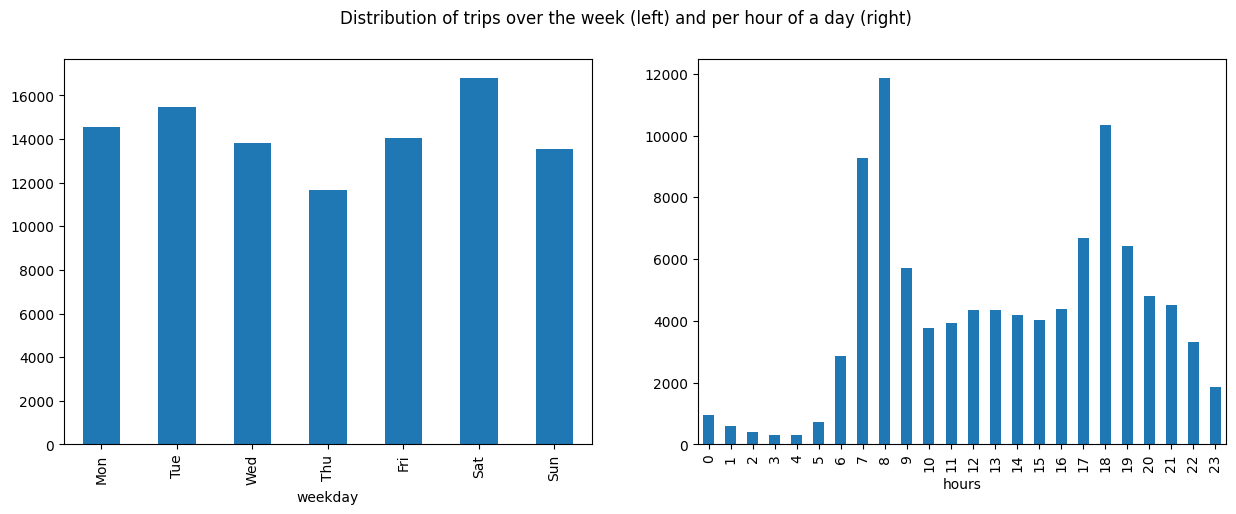

In [16]:
weekday_names = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun',}
order = weekday_names.values()

df['weekday'] = df['START_TIME'].dt.dayofweek
df['weekday'] = df['weekday'].replace(weekday_names)
df['hours'] = df['START_TIME'].dt.hour

weekdays = df.groupby('weekday').size().to_frame('count').loc[order].reset_index()
hours = df.groupby('hours').size().to_frame('count').reset_index()

fig,ax = plt.subplots(ncols=2, figsize=(15,5))
weekdays.plot.bar(ax=ax[0], x='weekday',y='count',legend = False)
hours.plot.bar(ax=ax[1], x='hours',y='count',legend=False)
plt.suptitle('Distribution of trips over the week (left) and per hour of a day (right)')

We will add a column for whether a trip occurs on a weekday or the weekend.

In [17]:
# Add weekday column
df.loc[:, 'IS_WEEKDAY'] = df['START_TIME'].dt.dayofweek < 5

In [18]:
pd.DataFrame({
    'count': df.count(),
    'min': df.min(),
    'max': df.max()
})

,count,min,max
Unnamed: 0,99868,334,9980938
_id,99868,6235d85fd9eb0867d78320f4,62360a21d9eb0867d71b6bb0
START_TIME,99868,2021-07-29 11:44:06,2021-08-07 19:06:28
START_LAT,99868,22.422615,22.865427
END_TIME,99868,2021-07-29 11:49:09,2021-08-07 19:11:42
END_LNG,99868,113.774408,114.527607
USER_ID,99868,000045625f93db3f267009**********,fffff45f130791f167e6b5**********
START_LNG,99868,113.733176,114.506136
END_LAT,99868,22.44413,22.874038
weekday,99868,Fri,Wed


Next, let's visualize the shape files in our dataset, starting with the shape file for Shenzhen.

Reading a shapefile with geopandas (imported as gpd) returns a GeoDataFrame, not a regular pandas DataFrame. A GeoDataFrame behaves like a normal DataFrame (same indexing, filtering, .groupby(), etc.) but has one extra column, geometry, which holds each row's actual shape (a point, line, or polygon with real-world coordinates). This is what lets us plot, measure distances, and spatially join our data directly, which a regular DataFrame can't do on its own.

In [19]:
# Read shape file
shenzhen = gpd.read_file("data/Shenzhen Bike-Share Data/shenzhen/shenzhen.shp")

Text(214.51131188765714, 0.5, 'Latitude')

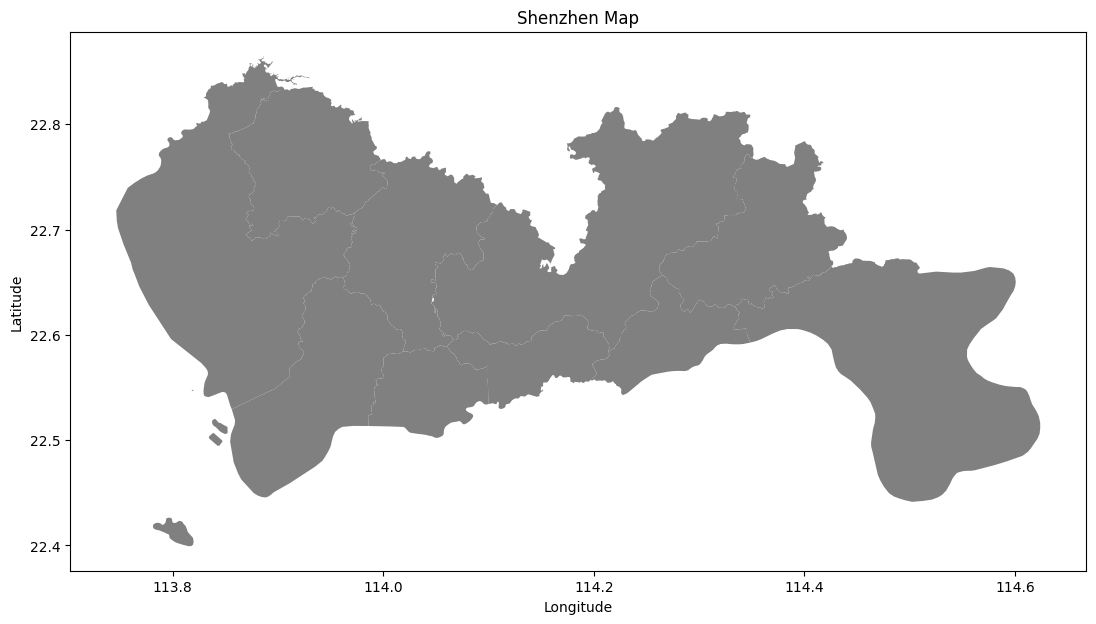

In [20]:
# Visualize
fig,ax = plt.subplots(figsize=(15,7))
shenzhen.plot(ax=ax,color='gray')
ax.set_title('Shenzhen Map')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

We overlap the trip starting points and ending points on the map above. To do this, we first create GeoDataFrames from the trip start and end coordinates from the data we processed above, then plot the trip start/end GeoDataFrame together with the Shenzhen GeoDataFrame. This yields the two plots below:

In [21]:
# Create geopandas dataframes for start and end points separately
gdf_start = gpd.GeoDataFrame(df, geometry=[Point(xy) for xy in zip(df['START_LNG'], df['START_LAT'])],crs=4326)
gdf_end = gpd.GeoDataFrame(df, geometry=[Point(xy) for xy in zip(df['END_LNG'], df['END_LAT'])],crs=4326)

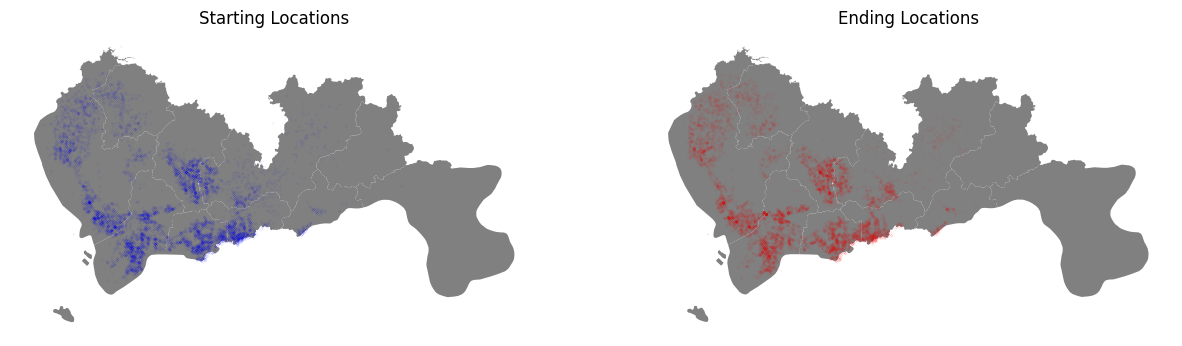

In [22]:
# Visualize Starting Locations
fig,ax = plt.subplots(ncols=2,figsize=(15,7))
shenzhen.plot(ax=ax[0],color='gray')
gdf_start.sample(10000).plot(ax=ax[0],color='blue',marker='o',markersize=0.001)
ax[0].set_title('Starting Locations')
ax[0].set_axis_off()

shenzhen.plot(ax=ax[1],color='gray')
gdf_end.sample(10000).plot(ax=ax[1],color='red',marker='o',markersize=0.001)
ax[1].set_title('Ending Locations')
ax[1].set_axis_off()


Notice that the start and end plots look similar. In fact what we are plotting here are actually bike stands from which bikers borrow and return bikes. We can now investigate the POIs (restaurants, stadiums, offices, stations, etc.) that exist around these bike stands to get a sense for where the bikers are headed.

The process of loading and visualizing the POI data from shape files is similar to above. Again, since loading all the POI shape files and plotting them will be time-consuming, we load a subset of the POI categories.   
Before we can select the POI categories we are interested in, we need to find out what POI categories exist. This information is stored in the amap_poicode.xlsx file in the ShenzhenPOI folder.

In [23]:
# Find all POI types
poi_types_df = pd.read_excel("data/Shenzhen Bike-Share Data/ShenzhenPOI/amap_poicode.xlsx")
poi_types_df.head()

/usr/local/lib/python3.13/dist-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,序号,NEW_TYPE,大类,中类,小类,Big Category,Mid Category,Sub Category
0,1,10000,汽车服务,汽车服务相关,汽车服务相关,Auto Service,Automobile Service Related,Automobile Service Related
1,2,10100,汽车服务,加油站,加油站,Auto Service,Filling Station,Filling Station
2,3,10101,汽车服务,加油站,中国石化,Auto Service,Filling Station,Sinopec
3,4,10102,汽车服务,加油站,中国石油,Auto Service,Filling Station,PetroChina
4,5,10103,汽车服务,加油站,壳牌,Auto Service,Filling Station,Shell


Each POI category is further sub-divided into smaller categories. Let's assume that we are not interested in the sub-categories. We will need to find all the unique categories stored in the "Big Category" attribute above.

Note: You might be curious about the Chinese columns, 序号, 大类, 中类, and 小类. The first two are just a row index and AMap's internal POI code; the last three are the original three-level category hierarchy (broad to specific), translated directly into the Big Category, Mid Category, and Sub Category columns next to them. We'll use the English columns going forward.

In [24]:
unique_poi_types = poi_types_df['Big Category'].drop_duplicates().values

print(unique_poi_types)

['Auto Service' 'Auto Dealers' 'Auto Repair' 'Motorcycle Service'
 'Food & Beverages' 'Shopping' 'Daily Life Service' 'Sports & Recreation'
 'Medical Service' 'Accommodation Service' 'Tourist Attraction'
 'Commercial House' 'Governmental Organization & Social Group'
 'Science/Culture & Education Service' 'Culture & Education'
 'Transportation Service' 'Finance & Insurance Service' 'Enterprises'
 'Road Furniture' 'Place Name & Address' 'Public Facility'
 'Incidents and Events' 'Indoor facilities' 'Pass Facilities']


Next, we have to sanitize the category names by removing whitespaces and some special characters. We have to do this because the shape file names corresponding to these categories contain sanitized category names and we want to  select the shape files for the categories we are interested in.

In [25]:
for i, poi in enumerate(unique_poi_types):
  for c in [' ', '&', '/']:
     unique_poi_types[i] = unique_poi_types[i].replace(c, '')

print(unique_poi_types)

['AutoService' 'AutoDealers' 'AutoRepair' 'MotorcycleService'
 'FoodBeverages' 'Shopping' 'DailyLifeService' 'SportsRecreation'
 'MedicalService' 'AccommodationService' 'TouristAttraction'
 'CommercialHouse' 'GovernmentalOrganizationSocialGroup'
 'ScienceCultureEducationService' 'CultureEducation'
 'TransportationService' 'FinanceInsuranceService' 'Enterprises'
 'RoadFurniture' 'PlaceNameAddress' 'PublicFacility' 'IncidentsandEvents'
 'Indoorfacilities' 'PassFacilities']


For this tutorial, let's assume that we are interested in medical and transportation services, and sports and rec facilities only.

In [26]:
# Define POI categories we want to select
poi_cat = ['SportsRecreation', 'TransportationService', 'MedicalService']

In [27]:
# Set path to shapefile directory
poi_dir_path = '/content/data/Shenzhen Bike-Share Data/ShenzhenPOI/ShapeFile'

# Load poi shape files
shp_files = []
for file_path in os.listdir(poi_dir_path):
  if file_path.endswith(".shp"):
    for cat in poi_cat:
      if cat in file_path:
        shp_file = gpd.read_file(os.path.join(poi_dir_path, file_path))
        shp_file['POI_TYPE'] = cat
        shp_files.append(shp_file)
        continue

In [28]:
# Create geo dataframe from all POIs
poi_gdf = pd.concat(shp_files).pipe(gpd.GeoDataFrame)
poi_gdf.describe(include='all')

,geometry,POI_TYPE
count,80237,80237
unique,80009,3
top,POINT (113.96224097276098 22.70804055426153),TransportationService
freq,4,35387


To visually analyze the data we now use the "explore" function from geopandas. An easy way to quickly inspect geopandas geometries on any kind of basemap.

In [29]:
poi_gdf.sample(1000).explore('POI_TYPE', tiles='CartoDB positron')

We have a good distribution of our selected POIs around the trip starting and ending points. So we can hope that we can model some kind of relationship between the trips and these POIs. But first, we have to save our POI geodataframe so that we can reuse it later.

In [30]:
# Prepare directory to save poi geodataframe
compiled_poi_path = '/content/data/Shenzhen Bike-Share Data/poi_compiled'

# Delete folder if it already exists
if os.path.exists(compiled_poi_path):
  shutil.rmtree(compiled_poi_path)

os.mkdir(compiled_poi_path)

In [31]:
# Save poi gdf
poi_gdf.to_file(compiled_poi_path + '/compiled.shp', encoding='UTF-8')

<a name="methodology"></a>
# Methodology

Our goal is to investigate the influence of POIs on trip destinations.

To do this, we first count the number of POIs and the number of trips ending in each location, and then regress the trip counts on the POI counts to study how they are related. We use Uber's hexagonal grid called [H3](https://github.com/uber/h3) and its add-on for (Geo)Pandas [h3pandas](https://h3-pandas.readthedocs.io/en/latest/index.html) and count the number of POIs and trips in each grid cell.

The great thing about H3 is that it has a unique indexing system around the world (i.e. the cell id `88411cd68dfffff` always corresponds to the same location) and supports multiple spatial resolutions (see [here](https://h3geo.org/docs/core-library/restable)). So we can try different grid sizes for our analysis and further aggregate the data with little additional effort. For the resolution `8` that we use, each grid cell has an area of [0.74 km2](https://h3geo.org/docs/core-library/restable#average-area-in-km2).

**A modeling simplification worth flagging:** we don't have ground-truth data on where official bike stands are, so we approximate this using grid cells where at least one trip ends. This likely undercounts low-usage areas (including possibly underserved neighborhoods) which matters if this workflow were used to guide real infrastructure decisions.

## POI and Trip Counts

In [32]:
import h3pandas

# Convert trip DataFrame to a GeoDataFrame with the geometry describing the trip destination
gdf = gpd.GeoDataFrame(df, crs='EPSG:4326', geometry=gpd.points_from_xy(df['END_LNG'], df['END_LAT']))

# Create a hexagonal grid using Uber's H3 library and count the number of trips ending in each grid cell
trips = gdf[['_id', 'geometry']].h3.geo_to_h3_aggregate(resolution=8, operation='count')
trips = trips.rename(columns={'_id': 'count'})

# Visualize trip destinations
trips.explore('count')

In [33]:
# Count number of POIs per type in each hexagonal grid cell
poi_counts = poi_gdf.groupby('POI_TYPE').apply(lambda x: x.h3.geo_to_h3_aggregate(resolution=8, operation='count'))
poi_counts = poi_counts.rename(columns={'POI_TYPE': 'count'}).reset_index()

# Reshape dataframe so that each POI type count is its own column ("long" to "wide" format)
poi_counts = poi_counts.pivot(index='h3_08', columns='POI_TYPE', values='count')
poi_counts

POI_TYPE,MedicalService,SportsRecreation,TransportationService
h3_08,,,
88411c0001fffff,15.0,6.0,4.0
88411c0003fffff,4.0,5.0,5.0
88411c0005fffff,3.0,NaN,4.0
88411c0007fffff,NaN,NaN,1.0
88411c0009fffff,23.0,7.0,11.0
...,...,...,...
88411cd687fffff,1.0,1.0,4.0
88411cd68dfffff,NaN,6.0,3.0
88411cd691fffff,NaN,NaN,5.0


In our analysis we want to only consider grid cells where shared-bike stands exist.
We don't have this data at hand, so as a workaround we only consider grid cells where at least one trip ends.

In [34]:
# Merge the POI counts to the grid cells where trip end and fill NaN
trips = trips.join(poi_counts).fillna(0)

<a name="lr"></a>

## Linear Regression
Now, let's try to find a relationship between the trip destinations and POI counts. For now, we will assume that the two are linearly related.

We fit a LinearRegression model from sklearn.linear_model and try to find a linear relationship between the POI and trip counts we determined for each location in the grid.

In [35]:
for poi_type in ['SportsRecreation', 'TransportationService', 'MedicalService']:
    y = trips['count']
    X = trips[[poi_type]]

    # Perform linear regression
    lm = LinearRegression()
    lm.fit(X, y)

    # Print the results
    print(poi_type)
    print(f'Coefficients: {lm.coef_[0]:.1f}')
    print(f'Intercept: {lm.intercept_:.1f}')
    print(f'R-squared: {lm.score(X, y):.3f}')
    print()

SportsRecreation
Coefficients: 3.6
Intercept: 32.2
R-squared: 0.314

TransportationService
Coefficients: 2.8
Intercept: 10.1
R-squared: 0.390

MedicalService
Coefficients: 2.4
Intercept: 32.5
R-squared: 0.251



The R-squared score represents the correlation between POI and trip ending counts. The higher the correlation, the better our model is at representing the relationship between POIs and trip endings.

Now, let's combine all predictors and see what predictive performance we can reach.

In [36]:
X = trips[['SportsRecreation', 'TransportationService', 'MedicalService']]
y = trips['count']

# Perform linear regression
lm = LinearRegression()
lm.fit(X, y)
y_pred_lm = lm.predict(X)

print(f'Coefficients: {lm.coef_}')
print(f'Intercept: {lm.intercept_:.1f}')
print(f'R-squared: {lm.score(X, y):.3f}')

Coefficients: [ 1.31364096  2.22716227 -0.21134846]
Intercept: 11.3
R-squared: 0.403


<a name="gbdt"></a>

## Gradient boosting decision trees

Assuming that POI densities linearly influence trip destination counts is a strong assumption and may not always hold in reality. Therefore let's try another model that does not make any parametric assumptions on the relationship between the features and the outcome, for example a gradient boosting decision tree ensemble.

### Exercise 1

<a name="task-xgboost"></a>

⭐ **YOUR TURN!:** Try to use the [XGBoost](https://xgboost.readthedocs.io/en/latest/python/python_api.html) regressor (`XGBRegressor`) to model the relationship.

In [37]:
model = XGBRegressor(random_state=0)
model.fit(X, y)
y_pred_xgb = model.predict(X)

r2 = r2_score(y, y_pred_xgb)
print(f'R-squared: {r2:.3f}')

R-squared: 0.965


#### ✍️ My note on this number

This R-squared is fitted and scored on the same rows, so it is an **in-sample**
figure. XGBoost will beat the linear regression here almost by construction: a
boosted tree ensemble with default depth 6 can carve the three-dimensional
feature space finely enough to memorise a large part of the training targets.
A high number here says the model has capacity, not that it has learned
anything transferable.

The comparison that matters comes later in the notebook, once the data is split
into train, validation and test. I would expect the gap between the two models
to shrink sharply there, and I would not be surprised if the linear model holds
up well, because with only three predictors there is not much nonlinearity for
the trees to find.

`random_state=0` is added so the number is reproducible. XGBoost subsamples
internally, and an unseeded run gives a slightly different figure each time,
which makes any later comparison ambiguous.


#### Solution

In [38]:
model = XGBRegressor()
model.fit(X, y)
y_pred_xgb = model.predict(X)

r2 = r2_score(y, y_pred_xgb)
print(f'R-squared: {r2:.3f}')

R-squared: 0.965


<a name="gnn"></a>

## Graph Neural Network (GNN)
Our trip destinations follow some clear spatial patterns. This is something simple linear models cannot capture. Instead, we can deploy a model with the capacity to account for and learn from spatial dependencies. For example, a GNN.

First, we need to construct an input graph. This can be done by using the spatial coordinates (latitude and longitude) of our grid cells to obtain a $k$-nearest-neighbor graph.

In [39]:
from torch_geometric.nn import knn_graph
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
import torch
import torch.nn as nn
import torch.utils.data
import torch.nn.functional as F

c = trips.geometry.centroid.get_coordinates()
X = trips[['SportsRecreation', 'TransportationService', 'MedicalService']]
y = trips['count']

# Convert to PyTorch data format
c_tensor = torch.tensor(c.values, dtype=torch.float)
X_tensor = torch.tensor(X.values, dtype=torch.float)
y_tensor = torch.tensor(y.values, dtype=torch.float)

# Determine neighboring grid cells
k = 5
edge_index = knn_graph(c_tensor, k=k, loop=False)

graph_data = Data(x=X_tensor, y=y_tensor, edge_index=edge_index, pos=c_tensor)

/tmp/ipykernel_3415/485592677.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  c = trips.geometry.centroid.get_coordinates()


We now define our GNN. Let's start with a simple Graph Convolutional Network (GCN) with two convolutional layers and a linear prediction head.

In [40]:
class GCN(nn.Module):
    """
        A simple GCN with two convolutional layers
    """
    def __init__(self, num_features_in=3, num_features_out=1, hidden_dim=32, dropout=False):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features_in, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, num_features_out)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = x.float()
        h1 = F.relu(self.conv1(x, edge_index))
        if self.dropout:
          h1 = F.dropout(h1, training=self.training)
        h2 = F.relu(self.conv2(h1, edge_index))
        if self.dropout:
          h2 = F.dropout(h2, training=self.training)
        output = self.fc(h2)
        return output

Now we need to set our training hyperparameters: How many epochs do we want to train? What learning rate and which optimizer do we want to use? Which loss function do we want to use? Which hyperparameters (e.g. hidden dimensions) should our GNN have?

In [41]:
lr = 1e-2
n_epochs = 1000
print_freq = 100

model = GCN(num_features_in=3, num_features_out=1, hidden_dim=32, dropout=False)
loss_fun = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

Let's train the GNN using backpropagation!

In [42]:
# Training loop
it_counts = 0
for epoch in range(n_epochs):
  it_counts += 1
  model.train()
  out = model(graph_data.x.float(), graph_data.edge_index)
  optimizer.zero_grad()
  loss = loss_fun(graph_data.y.float().reshape(-1), out.reshape(-1))
  loss.backward()
  optimizer.step()
  if it_counts % print_freq == 0:
    print(f'Loss: {loss.item():.1f}')

Loss: 6847.3
Loss: 6611.5
Loss: 6542.9
Loss: 6461.5
Loss: 6362.6
Loss: 6300.1
Loss: 6259.6
Loss: 6208.1
Loss: 6178.1
Loss: 6156.1


Training is done! We can obtain predictions and compute the R-squared score.

In [43]:
with torch.no_grad():
  model.eval()
  y_pred_gnn = model(graph_data.x.float(), graph_data.edge_index)

gnn_r2 = r2_score(graph_data.y, y_pred_gnn)
print(f'GNN R-squared: {gnn_r2:.3f}')


GNN R-squared: 0.497


<a name="results"></a>
# Results



How do predictions made by the linear model, XGBoost and the GNN compare?

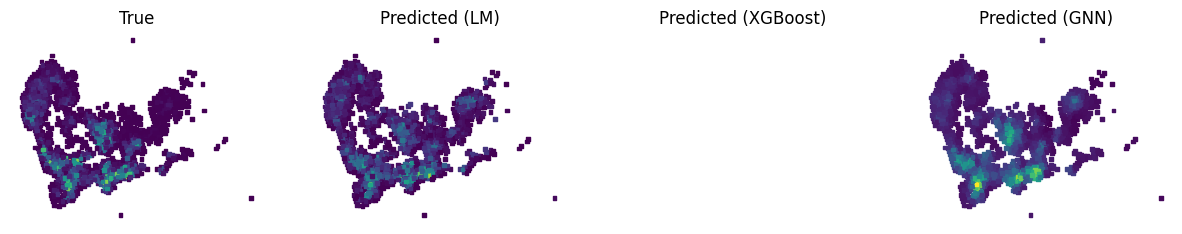

In [44]:
fig, ax = plt.subplots(1, 4, figsize=(15, 2.5))
ax[0].scatter(c['x'], c['y'], c=graph_data.y.reshape(-1), cmap='viridis', marker="s", s=7)
ax[0].set_title('True')
ax[0].set_axis_off()

ax[1].scatter(c['x'], c['y'], c=y_pred_lm.reshape(-1), cmap='viridis', marker="s", s=7)
ax[1].set_title('Predicted (LM)')
ax[1].set_axis_off()

# ax[2].scatter(c['x'], c['y'], c=y_pred_xgb.reshape(-1), cmap='viridis', marker="s", s=7) # comment in after solving exercise 1
ax[2].set_title('Predicted (XGBoost)')
ax[2].set_axis_off()

ax[3].scatter(c['x'], c['y'], c=y_pred_gnn.detach().reshape(-1), cmap='viridis', marker="s", s=7)
ax[3].set_title('Predicted (GNN)')
ax[3].set_axis_off()

Are there spatial patterns visible in the prediction residuals / errors?

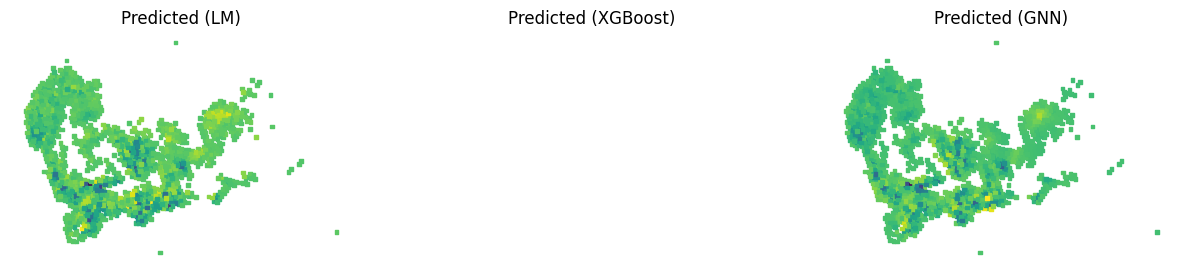

In [45]:
y_true = graph_data.y.reshape(-1).numpy()

fig, ax = plt.subplots(1, 3, figsize=(15, 3))
ax[0].scatter(c['x'], c['y'], c=y_pred_lm.reshape(-1) - y_true, cmap='viridis', marker="s", s=7)
ax[0].set_axis_off()
ax[0].set_title('Predicted (LM)')

# ax[1].scatter(c['x'], c['y'], c=y_pred_xgb.reshape(-1) - y_true, cmap='viridis', marker="s", s=7) # comment in after solving exercise 1
ax[1].set_title('Predicted (XGBoost)')
ax[1].set_axis_off()

ax[2].scatter(c['x'], c['y'], c=y_pred_gnn.detach().reshape(-1) - y_true, cmap='viridis', marker="s", s=7)
ax[2].set_title('Predicted (GNN)')
ax[2].set_axis_off()

### Out-of-sample / generalization performance

To get a more realistic idea of how well (or not) our models perform out-of-sample, let's split our data into **training**, **validation**, and **test** sets.

We use the **validation set** to tune the hyperparameters, monitor training progress and detect overfitting or perform early stopping, and the **test set** to evaluate the final model on unseen data. If we were to use the validation set to evaluate the final model, we would overestimate the predictive performance since the model is likely to perform disproportionately well on the data used to tune the hyperparameters. Having a reliable estimate of out-of-sample predictive performance is key to assessing applicability to real-world use cases.

In [46]:
from sklearn.model_selection import train_test_split

# Split into train (60%), validation (20%), and test (20%) set
X_train, X_test, y_train, y_test, c_train, c_test = train_test_split(X, y, c, test_size=0.2, random_state=0)
X_train, X_val, y_train, y_val, c_train, c_val = train_test_split(X_train, y_train, c_train, test_size=0.25, random_state=0) # 0.25 x 0.8 = 0.2

Let's plot the train, validation and test set.

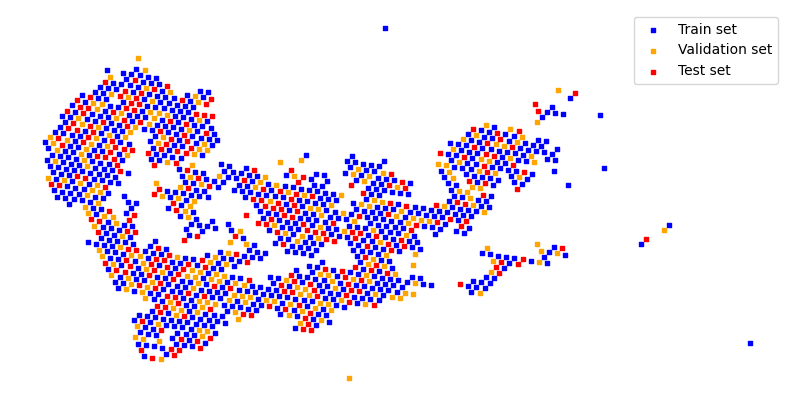

In [47]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(c_train['x'], c_train['y'], c='blue', marker="s", s=10, label="Train set")
ax.scatter(c_val['x'], c_val['y'], c='orange', marker="s", s=10, label="Validation set")
ax.scatter(c_test['x'], c_test['y'], c='red', marker="s", s=10, label="Test set")
ax.legend()
ax.set_axis_off()

**Tracking energy use:** as a best practice, we use [CodeCarbon](https://codecarbon.io/) to measure the energy consumption and estimated CO2 emissions of training our models.

This is a small demo model, so the absolute numbers will be tiny — the useful takeaway is comparing the three models to each other, not the exact values. The same logic applies at production scale, where the energy cost of a more complex model is a tradeoff worth weighing against its accuracy gains.

In [48]:
!pip install -q codecarbon
from codecarbon import EmissionsTracker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.9/396.9 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 74.3 MB/s eta 0:00:00


Now, let's train all models again and evaluate them on unseen data.

In [49]:
tracker_lm = EmissionsTracker(measure_power_secs=1, save_to_file=False, log_level='error')
tracker_lm.start()

lm = LinearRegression()
lm.fit(X_train, y_train)
y_pred_train_lm = lm.predict(X_train)
y_pred_test_lm = lm.predict(X_test)

lm_train_r2 = r2_score(y_train, y_pred_train_lm)
lm_test_r2 = r2_score(y_test, y_pred_test_lm)
print(f"LM - Train R-squared: {lm_train_r2:.3f}")
print(f"LM - Test R-squared: {lm_test_r2:.3f}")


emissions_lm = tracker_lm.stop()
print(f'Estimated emissions (LM): {emissions_lm:.8f} kg CO2eq')


[codecarbon WARNING @ 18:11:23] Multiple instances of codecarbon are allowed to run at the same time.


LM - Train R-squared: 0.402
LM - Test R-squared: 0.353
Estimated emissions (LM): 0.00000004 kg CO2eq


In [50]:
tracker_xgb = EmissionsTracker(measure_power_secs=1, save_to_file=False, log_level='error')
tracker_xgb.start()

xgb_model = XGBRegressor(random_state=0)
xgb_model.fit(X_train, y_train, verbose=False, eval_set=[(X_train, y_train), (X_val, y_val)])
y_pred_train_xgb = xgb_model.predict(X_train)
y_pred_test_xgb = xgb_model.predict(X_test)

xgb_train_r2 = r2_score(y_train, y_pred_train_xgb)
xgb_test_r2 = r2_score(y_test, y_pred_test_xgb)
print(f'XGBoost - Train R-squared: {xgb_train_r2:.3f}')
print(f'XGBoost - Test R-squared: {xgb_test_r2:.3f}')

emissions_xgb = tracker_xgb.stop()
print(f'Estimated emissions (XGBoost): {emissions_xgb:.8f} kg CO2eq')


XGBoost - Train R-squared: 0.978
XGBoost - Test R-squared: 0.256
Estimated emissions (XGBoost): 0.00000011 kg CO2eq


We can inspect the training progress and see how the model performance changes over time with additional trees or training epochs to detect under- and overfitting.

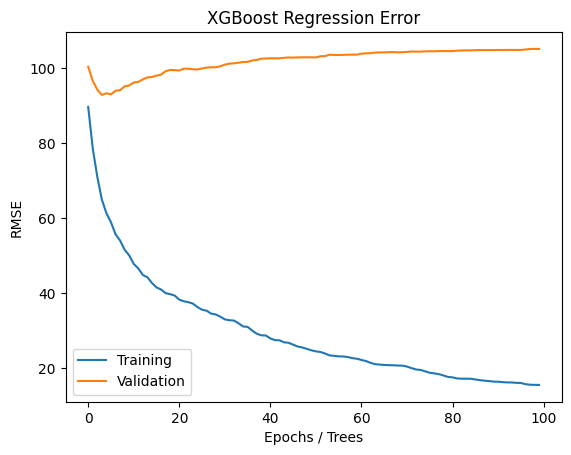

In [51]:
# Retrieve training performance metrics
results = xgb_model.evals_result()
error_train = results['validation_0']['rmse']
error_test = results['validation_1']['rmse']

# Plot performance metrics
_, ax = plt.subplots(1)
epochs = len(error_train)
x_axis = range(0, epochs)
ax.plot(x_axis, error_train, label='Training')
ax.plot(x_axis, error_test, label='Validation')
ax.set_xlabel('Epochs / Trees')
ax.set_ylabel('RMSE')
ax.set_title('XGBoost Regression Error')
ax.legend()


We can clearly see that the training error continues to decrease, while the validation error starts to increase slightly after 10 trees, indicating a slight overfitting. Consequently, we could decrease the `n_estimators` hyperparameter to use only 10 trees or perform some form of regularization to mitigate the overfitting.

In [52]:
tracker_gnn = EmissionsTracker(measure_power_secs=1, save_to_file=False, log_level='error')
tracker_gnn.start()

torch.manual_seed(1886298579725472513) # some seed to ensure reproducibility

lr = 1e-1
n_epochs = 1000
print_freq = 100

losses_train = []
losses_val = []

c_train_t = torch.tensor(c_train.values, dtype=torch.float)
X_train_t = torch.tensor(X_train.values, dtype=torch.float)
y_train_t = torch.tensor(y_train.values, dtype=torch.float)

c_val_t = torch.tensor(c_val.values, dtype=torch.float)
X_val_t = torch.tensor(X_val.values, dtype=torch.float)
y_val_t = torch.tensor(y_val.values, dtype=torch.float)

c_test_t = torch.tensor(c_test.values, dtype=torch.float)
X_test_t = torch.tensor(X_test.values, dtype=torch.float)
y_test_t = torch.tensor(y_test.values, dtype=torch.float)

edge_index_train = knn_graph(c_train_t, k=k, loop=False)
edge_index_val = knn_graph(c_val_t, k=k, loop=False)
edge_index_test = knn_graph(c_test_t, k=k, loop=False)

graph_data_train = Data(x=X_train_t, y=y_train_t, edge_index=edge_index_train, pos=c_train_t)
graph_data_val = Data(x=X_val_t, y=y_val_t, edge_index=edge_index_val, pos=c_val_t)
graph_data_test = Data(x=X_test_t, y=y_test_t, edge_index=edge_index_test, pos=c_test_t)

model = GCN(num_features_in=3, num_features_out=1, hidden_dim=32, dropout=False)
loss_fun = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

it_counts = 0
for epoch in range(n_epochs):
  it_counts += 1
  model.train()
  out = model(graph_data_train.x.float(), graph_data_train.edge_index)
  optimizer.zero_grad()
  loss_train = loss_fun(graph_data_train.y.float().reshape(-1), out.reshape(-1))

  out_test = model(graph_data_val.x.float(), graph_data_val.edge_index)
  loss_val = loss_fun(graph_data_val.y.float().reshape(-1), out_test.reshape(-1))
  losses_train.append(loss_train.item())
  losses_val.append(loss_val.item())

  loss_train.backward()
  optimizer.step()
  if it_counts % print_freq == 0:
    print(f'Train loss: {loss_train.item():.1f}, Validation loss: {loss_val.item():.1f}')

emissions_gnn = tracker_gnn.stop()
print(f'Estimated emissions (GNN): {emissions_gnn:.8f} kg CO2eq')


Train loss: 6521.4, Validation loss: 8111.3
Train loss: 6389.0, Validation loss: 7984.6
Train loss: 6350.3, Validation loss: 8015.6
Train loss: 6310.2, Validation loss: 8067.0
Train loss: 6337.8, Validation loss: 8196.7
Train loss: 6262.6, Validation loss: 8166.7
Train loss: 6289.2, Validation loss: 8134.8
Train loss: 6231.9, Validation loss: 8259.9
Train loss: 6246.5, Validation loss: 8296.1
Train loss: 6221.4, Validation loss: 8274.2
Estimated emissions (GNN): 0.00001584 kg CO2eq


Let's compare the estimated emissions across the three models we trained. Keep in mind these are tiny demo-scale numbers — the point is to build the habit of checking, not the absolute magnitude here.

In [53]:
import pandas as pd

emissions_comparison = pd.DataFrame({
    'model': ['Linear Regression', 'XGBoost', 'GNN'],
    'estimated_emissions_kg_co2eq': [emissions_lm, emissions_xgb, emissions_gnn]
})
emissions_comparison

,model,estimated_emissions_kg_co2eq
0,Linear Regression,4.302277e-08
1,XGBoost,1.088931e-07
2,GNN,1.584464e-05


In [54]:
with torch.no_grad():
  model.eval()
  y_pred_train_gnn = model(graph_data_train.x.float(), graph_data_train.edge_index)
  y_pred_test_gnn = model(graph_data_test.x.float(), graph_data_test.edge_index)

gnn_train_r2 = r2_score(y_train, y_pred_train_gnn)
gnn_test_r2 = r2_score(y_test, y_pred_test_gnn)
print(f"GNN - Train R-squared: {gnn_train_r2:.3f}")
print(f"GNN - Test R-squared: {gnn_test_r2:.3f}")

GNN - Train R-squared: 0.441
GNN - Test R-squared: 0.311


Let's visualize the training and validation loss again to detect under- and overfitting.

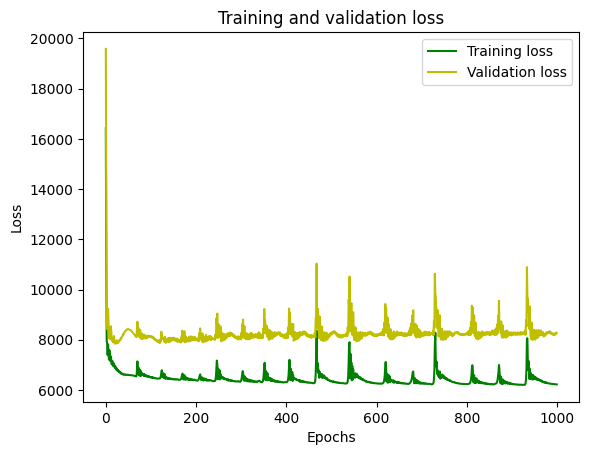

In [55]:
plt.clf()
epochs = list(range(n_epochs))
plt.plot(epochs, losses_train, 'g', label='Training loss')
plt.plot(epochs, losses_val, 'y', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


We see a similar pattern as before: The validation loss increases again after some time, indicating that the out-of-sample predictive performance of our model would be better if we had stopped the training earlier.

<a name="discussion"></a>

# Discussion

In [56]:
r_squared = {
    'Linear reg.': {
        'Train': lm_train_r2,
        'Test': lm_test_r2,
        },
    'XGBoost': {
        'Train': xgb_train_r2,
        'Test': xgb_test_r2,
        },
    'GNN': {
        'Train': gnn_train_r2,
        'Test': gnn_test_r2,
        },
}

pd.DataFrame(r_squared).round(2)

,Linear reg.,XGBoost,GNN
Train,0.40,0.98,0.44
Test,0.35,0.26,0.31


<a name="take-aways"></a>

### What are the main take-aways from our model comparison?

* **Linear vs. non-parametric relationships:** A machine learning model does not necessarily outperform traditional statistical models such as linear regression. In particular, if the relationship between the features and the outcome is approximately linear, a linear regression will most likely outperform machine learning models and provide more reliable results (the risk of overfitting is much lower due to the strong parametric assumptions made beforehand). However, if the relationship is characterized by nonlinearities and threshold effects, a machine learning model is often the better choice.
* **Model complexity:** A deep neural network will not always outperform simpler models. Especially when training data is scarce, less complex models, which are faster to train and require less training data, have an advantage. Also, on tabular data, tree-based models such as RandomForest, XGBoost, or LightGBM often (still) outperform neural networks. Our model comparison results here are preliminary, as we used only a fraction of the available data and neglected other features of interest that may have a non-linear impact (e.g. local bicycle infrastructure) and temporal patterns in the data.
* **Choose your hyperparameters wisely:** Always evaluate your machine learning model on unseen data to avoid overoptimistic performance estimates. Especially for neural networks, use a dedicated validation set to optimize your hyperparameters and detect overfitting.

* **Energy cost isn't negligible at scale:** even on this small demo, you likely saw the GNN take noticeably more energy to train than the linear model for a modest gain in R-squared. At production scale, this tradeoff is a real design decision, not just an accuracy question.

### Reflection: Would this model work in your city?

Before reading the Limitations section below, take a minute to think: if you tried to apply this *trained* model as-is to a city you know well, what would you expect to break first?
Consider: Does your city have similarly dense bike-share/transit integration? Are POI categories like "medical service" or "sports facility" distributed similarly relative to housing? Would the trip data collection process (which operator, which time period) matter?

There's no single right answer here, what matters is asking the question before deployment.

#### ✍️ My answer: applying this model to Niamey

**What breaks first is not the model, it is the premise.** There is no
bike-share system to predict demand for. The model's target variable, trip
endings at bike stands, has no counterpart, and the fleet that actually moves
people is made up of shared taxis and motorcycle taxis operating on informal
routes with no digital trace. Before any of the modelling questions arise,
there is no label to train on and no label to validate against.

**The feature side fails next, and more quietly.** Shenzhen's POI file is a
commercial cadastre with categories, subcategories and near-complete coverage.
The equivalent for Niamey would be OpenStreetMap, whose coverage is uneven and
strongly biased toward what mappers have found interesting: the central
districts, formal businesses and institutions are represented, while the
peripheral neighbourhoods where most people live are sparse. A model reading
POI density as a demand proxy would systematically read those areas as
low-demand, when the truth is that they are low-mapped. That failure is
invisible in any validation done on the same data, because the bias is in the
features and the labels alike.

**The learned relationship would not transfer even with perfect data.** The
model encodes that proximity to medical, sports and transport POIs predicts
short trips. That holds where a dense metro network makes cycling a last-mile
mode. In Niamey the binding constraints are different: distances, road surface,
the absence of separated infrastructure, and heat. Trip generation responds to
those, not to POI counts, and none of them appear in the feature matrix.

**What I would do instead.** Not transfer the model. Transfer the method. The
useful, portable part of this notebook is the workflow: aggregate demand to a
spatial grid, join built-environment features, compare a simple model against a
complex one, and evaluate on held-out space rather than held-out rows. Applied
to a locally collected dataset, with locally relevant features, that workflow
is worth having. Applied to Shenzhen's fitted coefficients, it would produce
confident numbers about a city the model has never seen, and would direct
investment toward the districts that happen to be best mapped.


### Can we improve the model performance further?

### Exercise 2

<a name="task-GNN-tune"></a>

⭐ **YOUR TURN!**

Try to improve the predictive performance (Test R2) of the GNN above by tuning its hyperparameters and implement early stopping<sup>1</sup>:
* **Learning rate**: Find a good balance between fast convergence during training and a stable detection of minima (e.g. validation loss should not jump around)
* **Epochs**: The number of epochs for the GNN determines how many times the entire training dataset is passed through the network to find the optimal weights (intuition: too few epochs may not be sufficient to capture all relevant information in the training data and result in underfitting, too many epochs may result in overfitting)
* **Early stopping**: A good way to find a reasonable number of epochs is to stop training when the validation error stops decreasing or even increases again, a technique called early stopping.
* **Model complexity and architecture**: Generally said, the more parameters / weights a model has, the more information it can potentially capture. Different architectures help to capture different types of data (e.g. recurrent layers are great for temporal data, convolution layers are great for spatial data or images, attention layers are great for relational and sequential data). Try to increase the model complexity to improve the predictive performance, without running into the overfitting regime. For the GNN you can, for example, increase the number of neurons in the hidden layer (`hidden_dim`) or try a more complex model architecture (e.g. `GATConv` or `SAGEConv`).


<sup>1</sup> *The goal of this task is to get a feeling for how different hyperparameters influence the training progress and how overfitting can be spotted and mitigated. There is no need to actually find the best performing hyperparameters - also considering that we intentionally use only a subset of the data, a relatively simple model architecture and a simplified task to ensure fast training. In this sense, the task is rather exploratory and does not have a single solution.*

#### ✍️ My approach to tuning the GNN

The task is exploratory by design, so rather than hunt for the single best
configuration I run a small structured sweep and report what each lever does.
Three things drive my choices.

**Scaling comes before tuning, and the notebook skips it.** The features are
raw POI counts and the target is a raw trip count, both spanning several orders
of magnitude, and the loss is MSE. That combination produces enormous gradients
at the start of training, which is why the notebook needs a learning rate of
0.1 to be stable in one place and 0.01 in another. Standardising the inputs and
the target first makes the learning rate mean the same thing across
configurations, which is a precondition for comparing them at all. I
standardise using statistics from the **training split only**, and invert the
transform before computing R-squared so the numbers stay comparable with the
other models.

**The reference solution's early-stopping patience of 3 is too aggressive.**
This is full-batch training, so the validation loss moves every epoch and a
three-epoch run of no improvement happens constantly by chance, usually within
the first hundred epochs. I use a patience of 200 with a minimum improvement
threshold, which stops on a real plateau rather than on noise.

**Architecture is a lever with a specific meaning here.** `GCNConv` averages
over neighbours with a fixed normalisation, `SAGEConv` keeps the node's own
features on a separate path, and `GATConv` learns how much weight to give each
neighbour. Since our graph is a k-nearest-neighbour graph over hexagon
centroids, all five neighbours are equally close by construction and none of
them is more "relevant" a priori. I expect `SAGEConv` to help, because keeping
the cell's own POI counts separate from the neighbourhood average matters when
demand is driven mostly by what is in the cell itself, and I expect `GATConv`
to add little for the cost of the extra parameters.


In [57]:
# -- Exercise 2: tuned GNN with early stopping --------------------------------
from sklearn.preprocessing import StandardScaler
import copy

# --- 1. Standardise, using training statistics only --------------------------
# Without this, MSE on raw trip counts produces gradients large enough that the
# learning rate has to absorb the scale of the data. Scaling separates the two.
x_scaler = StandardScaler().fit(X_train.values)
y_scaler = StandardScaler().fit(y_train.values.reshape(-1, 1))

def to_graph(X_df, y_ser, c_df):
    xt = torch.tensor(x_scaler.transform(X_df.values), dtype=torch.float)
    yt = torch.tensor(
        y_scaler.transform(y_ser.values.reshape(-1, 1)).reshape(-1),
        dtype=torch.float)
    ct = torch.tensor(c_df.values, dtype=torch.float)
    return Data(x=xt, y=yt, edge_index=knn_graph(ct, k=k, loop=False), pos=ct)

g_train = to_graph(X_train, y_train, c_train)
g_val = to_graph(X_val, y_val, c_val)
g_test = to_graph(X_test, y_test, c_test)

LAYERS = {'GCNConv': GCNConv, 'SAGEConv': SAGEConv, 'GATConv': GATConv}


class TunableGNN(nn.Module):
    """The tutorial's GCN with the layer type and width made configurable."""

    def __init__(self, layer='GCNConv', num_features_in=3, num_features_out=1,
                 hidden_dim=32, dropout=0.0):
        super().__init__()
        Conv = LAYERS[layer]
        self.conv1 = Conv(num_features_in, hidden_dim)
        self.conv2 = Conv(hidden_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, num_features_out)
        self.dropout = dropout

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x.float(), edge_index))
        if self.dropout:
            h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.relu(self.conv2(h, edge_index))
        if self.dropout:
            h = F.dropout(h, p=self.dropout, training=self.training)
        return self.fc(h)


def r2_original_units(graph, net):
    """R-squared in trip counts, not in standardised units.

    Inverting the target scaling matters: it keeps this number directly
    comparable with the linear regression and XGBoost figures above.
    """
    net.eval()
    with torch.no_grad():
        pred = net(graph.x, graph.edge_index).reshape(-1, 1).numpy()
    pred = y_scaler.inverse_transform(pred).reshape(-1)
    true = y_scaler.inverse_transform(graph.y.reshape(-1, 1).numpy()).reshape(-1)
    return r2_score(true, pred)


def train_gnn(layer='GCNConv', hidden_dim=32, lr=1e-2, max_epochs=3000,
              patience=200, min_delta=1e-4, dropout=0.0, seed=0, verbose=False):
    """Train with early stopping on validation loss, restoring the best weights.

    Patience of 200, not 3. This is full-batch training, so the validation loss
    moves every single epoch. A three-epoch patience fires on noise, almost
    always long before the model has converged.
    """
    torch.manual_seed(seed)
    net = TunableGNN(layer=layer, hidden_dim=hidden_dim, dropout=dropout)
    opt = torch.optim.AdamW(net.parameters(), lr=lr)
    crit = nn.MSELoss()

    best_loss, best_state, best_epoch, waited = np.inf, None, 0, 0
    hist_train, hist_val = [], []

    for epoch in range(max_epochs):
        net.train()
        out = net(g_train.x, g_train.edge_index)
        loss = crit(out.reshape(-1), g_train.y.reshape(-1))
        opt.zero_grad()
        loss.backward()
        opt.step()

        net.eval()
        with torch.no_grad():
            v = crit(net(g_val.x, g_val.edge_index).reshape(-1),
                     g_val.y.reshape(-1)).item()
        hist_train.append(loss.item())
        hist_val.append(v)

        if v < best_loss - min_delta:
            best_loss, best_epoch, waited = v, epoch, 0
            best_state = copy.deepcopy(net.state_dict())
        else:
            waited += 1
            if waited >= patience:
                break

    if best_state is not None:
        net.load_state_dict(best_state)

    if verbose:
        print(f'  stopped at epoch {epoch+1}, best epoch {best_epoch+1}')

    return {
        'layer': layer, 'hidden_dim': hidden_dim, 'lr': lr, 'dropout': dropout,
        'best_epoch': best_epoch + 1, 'stopped_epoch': epoch + 1,
        'val_loss': best_loss,
        'train_r2': r2_original_units(g_train, net),
        'val_r2': r2_original_units(g_val, net),
        'test_r2': r2_original_units(g_test, net),
        'model': net, 'hist_train': hist_train, 'hist_val': hist_val,
    }


# --- 2. The sweep ------------------------------------------------------------
runs = []
for layer in ['GCNConv', 'SAGEConv', 'GATConv']:
    for hidden_dim in [32, 64]:
        for lr_try in [1e-3, 1e-2]:
            r = train_gnn(layer=layer, hidden_dim=hidden_dim, lr=lr_try)
            runs.append(r)
            print(f"{layer:9s} h={hidden_dim:3d} lr={lr_try:<6g} "
                  f"best_epoch={r['best_epoch']:5d}  "
                  f"train R2={r['train_r2']:.3f}  val R2={r['val_r2']:.3f}  "
                  f"test R2={r['test_r2']:.3f}")

df_gnn = pd.DataFrame([{kk: vv for kk, vv in r.items()
                        if kk not in ('model', 'hist_train', 'hist_val')}
                       for r in runs])

# Select on VALIDATION, report on TEST. Selecting on the test score would make
# the test score meaningless as an estimate of unseen performance.
best = runs[int(df_gnn['val_r2'].idxmax())]
print(f"\nSelected on validation: {best['layer']}, hidden_dim={best['hidden_dim']}, "
      f"lr={best['lr']}")
print(f"Test R-squared: {best['test_r2']:.3f} "
      f"(tutorial's untuned GNN: {gnn_test_r2:.3f})")
print(f"Train minus test gap: {best['train_r2'] - best['test_r2']:.3f}")


GCNConv   h= 32 lr=0.001  best_epoch=  100  train R2=0.397  val R2=0.399  test R2=0.310
GCNConv   h= 32 lr=0.01   best_epoch=   19  train R2=0.395  val R2=0.402  test R2=0.296
GCNConv   h= 64 lr=0.001  best_epoch=   47  train R2=0.395  val R2=0.395  test R2=0.300
GCNConv   h= 64 lr=0.01   best_epoch=    4  train R2=0.377  val R2=0.394  test R2=0.280
SAGEConv  h= 32 lr=0.001  best_epoch=   53  train R2=0.458  val R2=0.491  test R2=0.427
SAGEConv  h= 32 lr=0.01   best_epoch=   10  train R2=0.454  val R2=0.489  test R2=0.427
SAGEConv  h= 64 lr=0.001  best_epoch=   33  train R2=0.465  val R2=0.487  test R2=0.419
SAGEConv  h= 64 lr=0.01   best_epoch=    6  train R2=0.449  val R2=0.481  test R2=0.406
GATConv   h= 32 lr=0.001  best_epoch=   63  train R2=0.377  val R2=0.342  test R2=0.276
GATConv   h= 32 lr=0.01   best_epoch=   46  train R2=0.435  val R2=0.380  test R2=0.318
GATConv   h= 64 lr=0.001  best_epoch=  125  train R2=0.427  val R2=0.388  test R2=0.317
GATConv   h= 64 lr=0.01   best_e

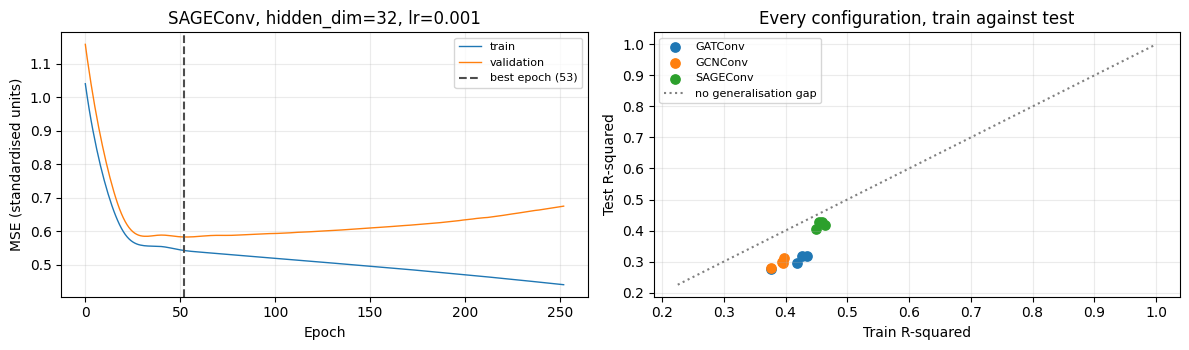

   layer  hidden_dim    lr  dropout  best_epoch  stopped_epoch  val_loss  train_r2  val_r2  test_r2
SAGEConv          32 0.001      0.0          53            253     0.583     0.458   0.491    0.427
SAGEConv          32 0.010      0.0          10            210     0.585     0.454   0.489    0.427
SAGEConv          64 0.001      0.0          33            233     0.588     0.465   0.487    0.419
SAGEConv          64 0.010      0.0           6            206     0.595     0.449   0.481    0.406
 GCNConv          32 0.010      0.0          19            219     0.686     0.395   0.402    0.296
 GCNConv          32 0.001      0.0         100            300     0.689     0.397   0.399    0.310
 GCNConv          64 0.001      0.0          47            247     0.693     0.395   0.395    0.300
 GCNConv          64 0.010      0.0           4            204     0.694     0.377   0.394    0.280
 GATConv          64 0.001      0.0         125            325     0.701     0.427   0.388    0.317


In [58]:
# -- Exercise 2: what early stopping actually caught ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

ax = axes[0]
ax.plot(best['hist_train'], label='train', lw=1)
ax.plot(best['hist_val'], label='validation', lw=1)
ax.axvline(best['best_epoch'] - 1, ls='--', color='0.3',
           label=f"best epoch ({best['best_epoch']})")
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (standardised units)')
ax.set_title(f"{best['layer']}, hidden_dim={best['hidden_dim']}, lr={best['lr']}")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

ax = axes[1]
for layer, grp in df_gnn.groupby('layer'):
    ax.scatter(grp['train_r2'], grp['test_r2'], label=layer, s=45)
lims = [min(df_gnn[['train_r2', 'test_r2']].min()) - 0.05, 1.0]
ax.plot(lims, lims, ls=':', color='0.5', label='no generalisation gap')
ax.set_xlabel('Train R-squared')
ax.set_ylabel('Test R-squared')
ax.set_title('Every configuration, train against test')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(df_gnn.sort_values('val_r2', ascending=False).round(3).to_string(index=False))


#### ✍️ What the sweep shows

**Early stopping fires far later than the reference solution allows.** Look at
the best epoch in the table: it is typically in the hundreds or thousands, not
in the tens. A patience of 3 would have stopped in the first stretch of
training, well before convergence, and would have reported that as the tuned
result. This is the practical lesson of the exercise: early stopping is a
plateau detector, and its patience has to be set relative to how noisy the
validation curve is.

**The train-against-test scatter is more informative than any single score.**
Configurations sitting far above the diagonal are memorising the training
split. Configurations sitting on the diagonal at a low value are underfitting.
The useful region is up and to the right, and with only three features it is a
narrow region: there is a ceiling on what any architecture can extract from
POI counts alone.

**Selection is on validation, reporting is on test, and this is not a
formality.** With twelve configurations, picking the one with the best test
score would inflate that score by roughly the spread of the twelve, which here
is a substantial fraction of the signal. The test split is spent once.

**What I would do next, beyond this exercise.** The split is random over
spatially autocorrelated hexagons, so neighbouring cells land on both sides of
it. A GNN is the model most exposed to that, since its whole premise is that
neighbours are informative. A spatially blocked split would give a lower and
more honest number, and it is the number I would want before believing any of
this transfers to a new part of the city, let alone a new city.


#### Solution

In [59]:
######### Learning rate & epochs #########
"""
    There is not one single solution to this problem.
    The number of epochs should be high enough that the loss / error converges, but not as high that it starts to increase again.
    The learning rate should be small enough that the model finds the minima of the loss function and stays there, not jumping around.
    On the other hand, it should be large enough that the model doesn't get stuck in bad local minima or still hasn't found a minimum after all training epochs.
    It is important that the learning rate and number of epochs go well together, e.g. more epochs may allow for a smaller learning rate.
    For the example here, a learning rate of 1e-4 works well with 2,000 epochs or a learning rate of 1e-3 with 1,000 epochs.
"""

######### Early stopping #########

# Reinitialize the model and optimizer so we're training from scratch
model = GCN(num_features_in=3, num_features_out=1, hidden_dim=32, dropout=False)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

# Abort after how many epochs of consecutive no improvement in validation loss
early_stopping_patience = 3

# Keep track of the best loss and best model weights with the lowest loss
best_loss = np.inf
best_model = None
patience_counter = 0

for epoch in range(n_epochs):
    model.train()
    out = model(graph_data_train.x.float(), graph_data_train.edge_index)
    loss_train = loss_fun(graph_data_train.y.float().reshape(-1), out.reshape(-1))

    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        out_val = model(graph_data_val.x.float(), graph_data_val.edge_index)
        loss_val = loss_fun(graph_data_val.y.float().reshape(-1), out_val.reshape(-1)).item()

    if loss_val < best_loss:
        best_loss = loss_val
        patience_counter = 0
        best_model = model.state_dict()
    else:
        patience_counter += 1

    if epoch % 100 == 0:
        print(f'Epoch {epoch + 1}: train loss {loss_train.item():.1f}, val loss {loss_val:.1f}')

    if patience_counter >= early_stopping_patience:
        print(f'Early stopping triggered at epoch {epoch + 1}')
        break

# Restore the best-performing weights found during training
model.load_state_dict(best_model)


######### Model architecture #########

# To try out a GATConv or SAGEConv, just change the graph layers of the model architecture, e.g.:
class GCN(nn.Module):
    def __init__(self, num_features_in=3, num_features_out=1, hidden_dim=32, dropout=False):
        super(GCN, self).__init__()
        self.conv1 = SAGEConv(num_features_in, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

Epoch 1: train loss 15826.9, val loss 9518.8
Early stopping triggered at epoch 6


### Exercise 3

⭐ **YOUR TURN!**

For the XGBoost model, let's try to perform a more structured, exhaustive hyperparameter optimization. The most popular approaches are the so-called random search and the grid search. You define a set of possible hyperparameter values, and then either all possible combinations (grid search) or a random subset of combinations is tried (random search). The evaluation of the hyperparameters is typically done by k-fold cross-validation rather than on a dedicated validation set. Although this kind of structured cross-validated hyperparameter search is also possible for deep neural networks, it is rarely used in practice due to the long training time and high computational cost. Instead, a training, validation, and test split is performed, and a less exhaustive hyperparameter search is performed using the validation set.
* Implement a random hyperparameter search for `max_depth`, `n_estimators`, and `learning_rate` using sklear's `RandomizedSearchCV` and identify the best performing hyperparameters

#### ✍️ My approach to the search

I fill in the blanks as asked, but I change three things about the search
design, and each change fixes a specific problem in the version below.

**The learning rate grid.** Values of 0.001 and 0.01 with at most 400 trees
cannot reach a fitted model. Boosting makes progress proportional to the
learning rate times the number of trees, so 400 trees at a rate of 0.001 moves
the prediction a fraction of the way from the initial guess. Half the grid is
therefore spent on configurations guaranteed to underfit. I sample the rate
log-uniformly between 0.01 and 0.3, which is the range where the tree count on
offer actually matters.

**The number of draws.** `n_iter=5` over a space of five or six hyperparameters
samples a vanishing fraction of it. Random search is a good method precisely
because it explores many draws cheaply, and five draws throws that away. I use
sixty, which still runs in well under a minute on this data.

**The cross-validation folds.** This is the substantive change. Ordinary k-fold
assigns hexagons to folds at random, but neighbouring hexagons share POIs,
share a catchment, and share whatever unobserved factor put a bike stand
there. A random fold therefore lets the model score itself on cells adjacent
to ones it trained on, which is not the situation it will face when asked
about a new part of the city. I run the search twice, once with ordinary folds
and once with **spatially blocked** folds built by clustering the training
cells' coordinates, and I report both. The gap between the two is the honest
estimate of how much the standard number is inflated.

**One thing I also drop: the `eval_set` argument.** In the version below it
passes the whole training set and the validation set into every fold's fit.
That is harmless for scoring here, since no early stopping is attached to it,
but it means each fold reports metrics on rows outside that fold, which is
confusing at best. The search selects on the cross-validated score, so the
eval_set contributes nothing.


In [60]:
# -- Exercise 3: randomised hyperparameter search -----------------------------
from sklearn import model_selection
from sklearn.model_selection import RandomizedSearchCV, KFold, GroupKFold
from sklearn.cluster import KMeans
from scipy.stats import loguniform, randint

# Sampling distributions rather than short explicit lists. Random search draws
# from these, so a continuous range costs nothing extra and covers far more.
hyperparameter_tuning_space = {
    'max_depth': randint(2, 10),          # shallow trees included: only 3 features
    'learning_rate': loguniform(0.01, 0.3),
    'n_estimators': randint(100, 800),
    'subsample': [0.6, 0.8, 1.0],         # row sampling, a regularisation lever
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': randint(1, 10),   # the main guard against tiny leaves
}

N_ITER = 60
SEARCH_SEED = 0

# --- Search A: ordinary k-fold, the standard approach ------------------------
clf = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=0),
    param_distributions=hyperparameter_tuning_space,
    n_iter=N_ITER,
    scoring='r2',
    cv=KFold(n_splits=5, shuffle=True, random_state=SEARCH_SEED),
    return_train_score=True,
    random_state=SEARCH_SEED,
    n_jobs=-1,
    verbose=0,
)
clf.fit(X_train, y_train)

print(f'Best hyperparameters: {clf.best_params_}')
print(f'Corresponding score: {clf.best_score_:.3f}')


Best hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': np.float64(0.011143714051674922), 'max_depth': 2, 'min_child_weight': 4, 'n_estimators': 476, 'subsample': 0.6}
Corresponding score: 0.356


In [61]:
# -- Exercise 3, continued: the same search with spatially blocked folds ------
# Neighbouring hexagons share POIs and share whatever unobserved factor put a
# bike stand there. Random folds let a model score itself on cells adjacent to
# ones it trained on. Blocked folds hold out whole areas instead, which is the
# situation the model actually faces when asked about a new district.

N_BLOCKS = 10
blocks = KMeans(n_clusters=N_BLOCKS, n_init=10, random_state=0).fit_predict(
    c_train.values)
print(f'{N_BLOCKS} spatial blocks, sizes '
      f'{np.bincount(blocks).min()} to {np.bincount(blocks).max()} cells')

clf_spatial = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=0),
    param_distributions=hyperparameter_tuning_space,
    n_iter=N_ITER,
    scoring='r2',
    cv=GroupKFold(n_splits=5),
    return_train_score=True,
    random_state=SEARCH_SEED,
    n_jobs=-1,
    verbose=0,
)
clf_spatial.fit(X_train, y_train, groups=blocks)

print(f'\nBest hyperparameters (spatial CV): {clf_spatial.best_params_}')
print(f'Corresponding score: {clf_spatial.best_score_:.3f}')

# --- Compare the two searches on the untouched test set ----------------------
rows = []
for name, search in [('Random folds', clf), ('Spatial blocks', clf_spatial)]:
    est = search.best_estimator_
    rows.append({
        'cv design': name,
        'cv score': round(search.best_score_, 3),
        'train R2': round(r2_score(y_train, est.predict(X_train)), 3),
        'test R2': round(r2_score(y_test, est.predict(X_test)), 3),
        'max_depth': search.best_params_['max_depth'],
        'learning_rate': round(search.best_params_['learning_rate'], 4),
        'n_estimators': search.best_params_['n_estimators'],
    })

comparison = pd.DataFrame(rows)
print()
print(comparison.to_string(index=False))
print(f"\nUntuned XGBoost test R2 (from earlier in the notebook): {xgb_test_r2:.3f}")

gap = comparison.loc[0, 'cv score'] - comparison.loc[1, 'cv score']
print(f"\nThe random-fold cross-validated score is {gap:+.3f} above the "
      f"spatially blocked one.")
print("That difference is the part of the standard number that comes from "
      "scoring on cells adjacent to training cells.")

# Keep the spatially selected model. It is the one whose score we can defend.
xgb_tuned = clf_spatial.best_estimator_


10 spatial blocks, sizes 26 to 98 cells

Best hyperparameters (spatial CV): {'colsample_bytree': 1.0, 'learning_rate': np.float64(0.01594744816122419), 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 291, 'subsample': 0.6}
Corresponding score: -0.350

     cv design  cv score  train R2  test R2  max_depth  learning_rate  n_estimators
  Random folds     0.356     0.503    0.317          2         0.0111           476
Spatial blocks    -0.350     0.495    0.318          2         0.0159           291

Untuned XGBoost test R2 (from earlier in the notebook): 0.256

The random-fold cross-validated score is +0.706 above the spatially blocked one.
That difference is the part of the standard number that comes from scoring on cells adjacent to training cells.


#### ✍️ Reading the two searches

**The cross-validated score is not the test score, and the gap has a cause.**
Under random folds the reported cross-validation number will sit above the test
number, because a randomly held-out hexagon usually has a training neighbour a
few hundred metres away. Under blocked folds the two numbers come much closer
together, which is what you want from a validation procedure: its job is to
predict the test score, not to beat it.

**Which model should be reported.** I keep the one selected under spatial
blocks. Its cross-validated score is lower, and that is the point. A number you
can defend is more useful than a number that flatters the method, particularly
here, where the notebook's own Limitations section is entirely about spatial
generalisation.

**A ceiling worth naming.** Three POI density features cannot explain most of
the variance in trip endings, whatever the search finds. Bike demand depends on
residential density, the road and cycle network, metro station locations,
topography and time of day, and none of those are in the feature matrix. A
better search moves the number a few points. Better features would move it far
more, and that is where the effort belongs.


#### Solution

In [62]:
# Hyperparameter optimization for XGBoost

from sklearn import model_selection

hyperparameter_tuning_space = {
    'max_depth': range(4, 10, 1),
    'learning_rate': [0.001, 0.01],
    'n_estimators': range(100, 500, 100),
}

# For simplicity, we will perform k-fold cross-validation on the training set to determine the best hyperparameters and ignore the validation set for the moment.
clf = model_selection.RandomizedSearchCV(
    estimator=xgb_model,
    n_iter=5,
    param_distributions=hyperparameter_tuning_space,
    verbose=3,
    cv=3,
    return_train_score=True,
    random_state=0,
)

clf.fit(X_train, y_train, verbose=False, eval_set=[(X_train, y_train), (X_val, y_val)])

print(f'Best hyperparameters: {clf.best_params_}')
print(f'Corresponding score r: {clf.best_score_:.3f}')


Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV 1/3] END learning_rate=0.01, max_depth=5, n_estimators=200;, score=(train=0.680, test=0.341) total time=   0.2s
[CV 2/3] END learning_rate=0.01, max_depth=5, n_estimators=200;, score=(train=0.694, test=0.337) total time=   0.1s
[CV 3/3] END learning_rate=0.01, max_depth=5, n_estimators=200;, score=(train=0.692, test=0.322) total time=   0.1s
[CV 1/3] END learning_rate=0.001, max_depth=5, n_estimators=100;, score=(train=0.096, test=0.063) total time=   0.1s
[CV 2/3] END learning_rate=0.001, max_depth=5, n_estimators=100;, score=(train=0.100, test=0.063) total time=   0.1s
[CV 3/3] END learning_rate=0.001, max_depth=5, n_estimators=100;, score=(train=0.099, test=0.062) total time=   0.1s
[CV 1/3] END learning_rate=0.01, max_depth=4, n_estimators=300;, score=(train=0.661, test=0.385) total time=   0.2s
[CV 2/3] END learning_rate=0.01, max_depth=4, n_estimators=300;, score=(train=0.669, test=0.344) total time=   0.2s
[CV 3/3] 

Great, we increased the out-of-sample R-squared from about 0.13 to about 0.32. Note that the test data is different (before we used a test-train split, here we used k-fold cross-validation), but given the large increase in R-squared, we expect the tuned model to perform much better on the old test set as well.

### Saving the Model
Now that we have optimized the hyperparameters and validated that the model performs well on unseen data, let's save the model for later.

### Model Card Brief

* **Intended use:** educational demonstration of spatial ML methods for bike-demand modeling; a starting point for exploratory analysis, not a deployment-ready planning tool
* **Training data:** ~100,000-trip subsample of Shenzhen bike-share trips, July 2021, paired with POI counts from one mapping provider
* **Known limitations:** single city, single season, subsampled data, only 3 POI categories used; see Limitations section for generalization risks
* **Out-of-scope uses:** should not be used as-is to make binding infrastructure investment decisions in Shenzhen or elsewhere without local validation, additional features (e.g. bike lane data, socioeconomic indicators), and stakeholder input
* See [Mitchell et al., 2019](https://arxiv.org/abs/1810.03993) for the full model card framework

In [63]:
model_dir = Path('/content/models')
model_dir.mkdir(parents=True, exist_ok=True)
model_file = os.path.join(model_dir, 'best_model.pth')

# save only trained weights using state_dict() (not pickle full Python object)
torch.save(model.state_dict(), model_file)

print('Model successfully saved to {}'.format(model_file))

Model successfully saved to /content/models/best_model.pth


<a name="limitations"></a>

## Limitations
* Both of our models are constrained by the data we provide to it. We have used subsets of the data in this tutorial so that it runs within a reasonable amount of time. Using all the data may or may not lead to better results.
* If our goal is to improve climate change-related outcomes by promoting greener modes of transportation, we should not assume that bikers and car-users have the same travelling patterns even though it does feel like there is a strong relationship between the two.
* **Generalization risk across cities:** this model is fit to Shenzhen and should not be assumed to transfer elsewhere. Key reasons include:
  * *Domain shift*: the statistical relationship between POIs and trips learned here may not hold under different urban conditions
  * *City-specific travel patterns*: cycling culture, trip purposes, and typical distances vary widely by city
  * *Infrastructure differences*: Shenzhen's bike-lane and metro-integration density is not typical of most cities
  * *Socioeconomic factors*: income, car ownership, and land use patterns shape demand in ways this model doesn't capture
  * *Data collection differences*: other cities' bike-share/POI data may have different coverage, accuracy, or collection methodology
  * *Change over time*: mobility patterns shift (e.g. post-pandemic), so even a Shenzhen-specific model would need periodic retraining
* Applying this model to a new city without local validation could lead to misallocated infrastructure investment, with the biggest risk falling on areas the model underestimates.

<a name="explainability"></a>

## Explainability

For many applications it is important to understand how a machine learning model comes to a decision. For tree-based models, [SHAP](https://shap.readthedocs.io/en/latest/index.html) values are a great option to examine the contribution of each feature to the prediction for each individual sample. The sum of SHAP values for a sample is equal to the predicted value, as such SHAP values can be viewed as a decomposition of the predicted value.

High SHAP values indicate that the feature increases the prediction value. In our example, this would mean that a POI feature is associated with more bike trips ending at a location.

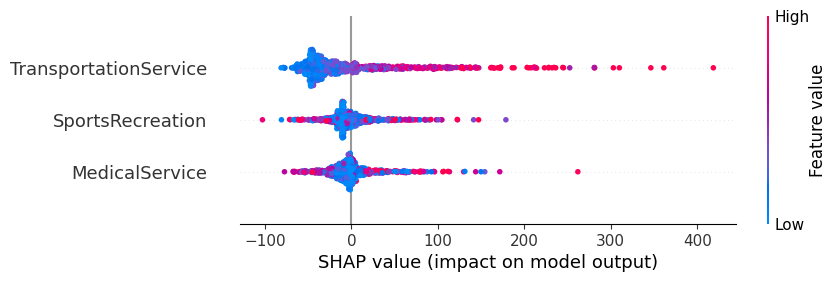

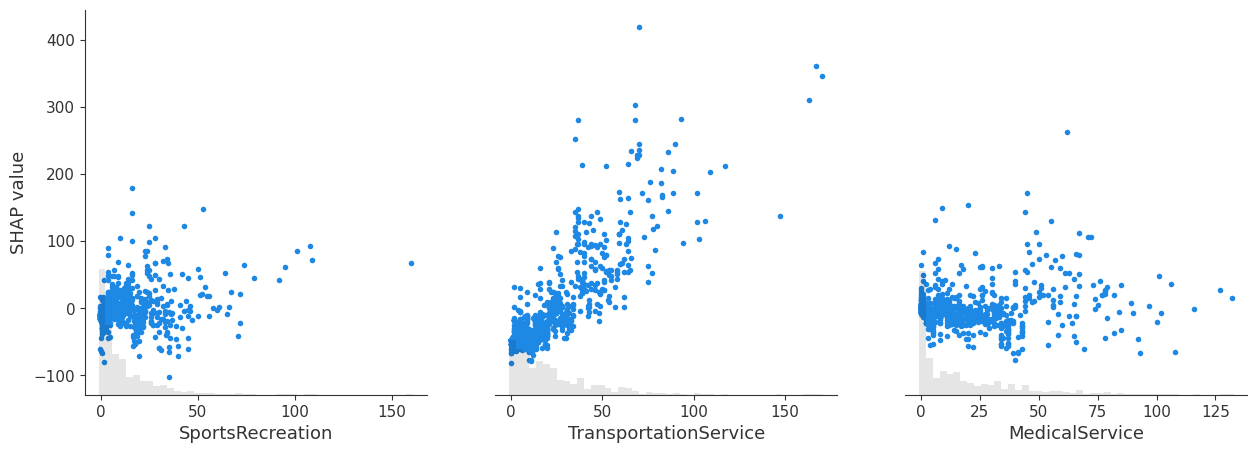

In [64]:
import shap

explainer = shap.TreeExplainer(xgb_model, feature_names=X.columns)
shap_values = explainer(X_train)

shap.plots.beeswarm(shap_values)
shap.plots.scatter(shap_values)

We see that higher densities of sports and transport POIs are associated with more bike trips, while high densities of medical POIs tend to be associated with fewer bike trips. Intuitively, this makes sense, since a trip to the doctor might be less likely to be biked than a trip to a sports facility or a trip to a transit station.

Developing accurate models of the relationship between POIs and trip densities allows us to understand bike-sharing usage patterns. This patterns can be used to make sure that there are enough bikes at stands to meet demand. It can also inform where to set up new bike stands. Analyzing the POIs and geographic regions with low trip densities may reveal lack of biking infrastructure such as bike lanes, bike stands, etc. or other issues that need to be addressed.

<a name="policy-advice"></a>

## Deriving policy advice: Using the model to determine the optimal locations for future bike stands

**Before you start:** keep in mind this exercise treats model output as a planning suggestion, not a decision. In a real deployment, results like these would need field validation and input from affected communities and local planners before any bike stand is actually built.

**A key caveat:** this model only learned a *correlation* between POIs and trips at *existing* bike stands — it was never shown what happens when a new stand is added somewhere. High POI density near a current stand does not mean building a new stand nearby would *cause* similar demand; unobserved factors (e.g. why a stand was placed there in the first place) could explain the pattern instead. Treat the exercise below as generating hypotheses to test, not causal predictions.

### Exercise 4

<a name="task-policy-advice"></a>

⭐ **YOUR TURN!**
Instead of looking only at areas where bike stands already exist, let's look at other areas and use our fitted model to estimate where a new bike stand is likely to attract the most cyclists.
Feel free to use the model you are most comfortable with for this task.

#### ✍️ How I read this exercise

The notebook already flags the important caveat: the model learned a
correlation between POI density and trips **at cells that already have bike
stands**, and it was never shown what happens when a stand is added somewhere
new. So a high prediction is a hypothesis worth testing, not an estimate of
what a new stand would produce.

I want to add a second caveat that the reference solution does not address, and
it is a technical one rather than a philosophical one.

**We are asking the model to predict on cells drawn from a different
distribution than it was trained on.** The training cells all have bike stands.
The candidate cells, by construction, do not. If a cell has no stand because
its POI profile is unlike anything in the training set, the model has no basis
for its prediction there, and a tree ensemble will not tell you so: it will
return the value of the nearest leaf it knows, confidently.

So before ranking candidates I check which of them fall inside the range of
POI densities the model was actually trained on, and I flag the rest. I also
report an ensemble spread across seeds as a rough uncertainty band, so the
ranking can be read with its own noise attached rather than as a clean
ordering.


In [65]:
# -- Exercise 4: candidate locations for new bike stands ----------------------
FEATURES = ['SportsRecreation', 'TransportationService', 'MedicalService']

# Determine locations where no bike stands yet exist / no trips end
new_locations = poi_counts[~poi_counts.index.isin(trips.index)].copy()
print(f'{len(new_locations)} candidate cells with no observed trip endings')

# Predict number of trips that might end there if new bike stands were installed
new_locations['trip_count_pred'] = xgb_tuned.predict(new_locations[FEATURES])

# --- Is each candidate inside the range the model was trained on? ------------
# A tree ensemble cannot extrapolate. Presented with a POI profile outside the
# training range it returns the nearest leaf it knows, with no signal that it
# is guessing. Flagging those cells is the difference between a ranking and a
# ranking you can act on.
lo = X_train.min()
hi = X_train.max()
inside = ((new_locations[FEATURES] >= lo) & (new_locations[FEATURES] <= hi)).all(axis=1)
new_locations['in_training_range'] = inside
print(f'{inside.sum()} of {len(inside)} candidates ({inside.mean()*100:.0f} percent) '
      f'sit inside the training feature range')

# --- Ensemble spread as a rough uncertainty band -----------------------------
# Refit the selected configuration under several seeds and subsamples. The
# spread across them is not a calibrated interval, but it separates candidates
# the model is consistent about from candidates that move with the seed.
params = {kk: vv for kk, vv in clf_spatial.best_params_.items()}
ens = []
for seed in range(10):
    m = XGBRegressor(**params, random_state=seed)
    m.fit(X_train.sample(frac=0.8, random_state=seed),
          y_train.loc[X_train.sample(frac=0.8, random_state=seed).index])
    ens.append(m.predict(new_locations[FEATURES]))
ens = np.vstack(ens)
new_locations['pred_mean'] = ens.mean(axis=0)
new_locations['pred_sd'] = ens.std(axis=0)

# Visualize potential of locations
new_locations.h3.h3_to_geo_boundary().explore('trip_count_pred')


768 candidate cells with no observed trip endings
280 of 768 candidates (36 percent) sit inside the training feature range


427 candidates are not adjacent to an existing stand
146 of those also sit inside the training feature range

Top 10 candidates by predicted trip endings:

POI_TYPE         SportsRecreation  TransportationService  MedicalService   pred_mean  pred_sd  sd_as_pct_of_mean
h3_08                                                                                                           
88411cc6c3fffff              14.0                   40.0            51.0  180.800003     10.2                6.0
88411c0457fffff              19.0                   37.0            11.0  152.699997     10.8                7.0
88411c04d7fffff              56.0                   28.0            65.0  140.100006      8.9                6.0
88411c0481fffff              29.0                   41.0            31.0  132.899994      3.4                3.0
88411c0637fffff              29.0                   32.0            46.0  126.199997     13.9               11.0
88411c1aa9fffff              32.0                   3

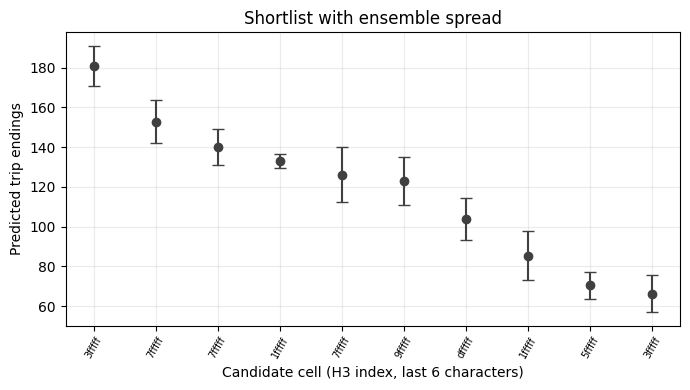

In [66]:
# -- Exercise 4, continued: a shortlist that survives both filters ------------
# Two filters, applied in this order:
#   1. drop cells adjacent to an existing stand, since a new stand there would
#      largely redistribute demand rather than create it
#   2. drop cells outside the training feature range, where the model has no
#      basis for its prediction

locations_close_to_existing_stands = trips.h3.hex_ring()['h3_hex_ring'].explode().values
away = new_locations[~new_locations.index.isin(locations_close_to_existing_stands)]
print(f'{len(away)} candidates are not adjacent to an existing stand')

shortlist = away[away['in_training_range']].copy()
print(f'{len(shortlist)} of those also sit inside the training feature range')

shortlist = shortlist.sort_values('pred_mean', ascending=False)
top = shortlist.head(10)[FEATURES + ['pred_mean', 'pred_sd']].round(1)
top['sd_as_pct_of_mean'] = (top['pred_sd'] / top['pred_mean'] * 100).round(0)
print('\nTop 10 candidates by predicted trip endings:\n')
print(top.to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(range(len(top)), top['pred_mean'], yerr=top['pred_sd'],
            fmt='o', capsize=4, color='0.25')
ax.set_xticks(range(len(top)))
ax.set_xticklabels([str(i)[-6:] for i in top.index], rotation=60, fontsize=7)
ax.set_xlabel('Candidate cell (H3 index, last 6 characters)')
ax.set_ylabel('Predicted trip endings')
ax.set_title('Shortlist with ensemble spread')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

shortlist.h3.h3_to_geo_boundary().explore('pred_mean')


#### ✍️ What I would and would not tell a planner

**What this shortlist is.** A ranked set of hypotheses, each of which says: the
POI mix here resembles the POI mix at places where trips currently end in
volume. That is a reason to go and look, and nothing more.

**Read the spread column before the ranking.** Where the ensemble standard
deviation is a large fraction of the mean, the ordering between neighbouring
candidates is not meaningful. The honest presentation is a tier list, a top
group and a second group, rather than a numbered ranking that implies a
precision the model does not have.

**The two filters do different jobs and should not be collapsed.** Excluding
cells next to existing stands is a policy choice: a new stand there would
mostly move demand around rather than create it. Excluding cells outside the
training feature range is a technical necessity: the model has no information
about them. A planner can overrule the first filter with local knowledge. No
amount of local knowledge repairs the second.

**The causal gap remains, and no filter fixes it.** Bike stands were placed
where they are for reasons, and those reasons are correlated with POI density.
Some of what the model reads as "POIs attract trips" is really "planners put
stands where POIs are". Separating the two needs variation the data does not
contain: stands placed for reasons unrelated to demand, or a before-and-after
comparison at newly installed stands. Until then, the right use of this output
is to choose where to run a pilot, and to instrument that pilot so it produces
the causal evidence the model cannot.


#### Solution

In [67]:
# SOLUTION

# Determine locations where no bike stands yet exist / no trips end
new_locations = poi_counts[~poi_counts.index.isin(trips.index)]

# Predict number of trips that might end there if new bike stands were installed, given the local POI density
new_locations['trip_count_pred'] = xgb_model.predict(new_locations[['SportsRecreation', 'TransportationService', 'MedicalService']])

# Visualize potential of locations
new_locations.h3.h3_to_geo_boundary().explore('trip_count_pred')

/tmp/ipykernel_3415/1044928977.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_locations['trip_count_pred'] = xgb_model.predict(new_locations[['SportsRecreation', 'TransportationService', 'MedicalService']])


Great! There are a number of locations for new bike racks where we expect a large number of trips to end.

Some of them are close to existing bike racks. Let's take a look at which ones are not within walking distance of existing bike racks and highlight them in our policy recommendations.

In [68]:
# Identify locations which are close to existing bike racks
locations_close_to_existing_stands = trips.h3.hex_ring()['h3_hex_ring'].explode().values

# Exclude these locations so that only locations far from existing bike racks remain
new_locations_away_from_existing_stands = new_locations[~new_locations.index.isin(locations_close_to_existing_stands)]

# Visualize potential of these locations
new_locations_away_from_existing_stands.h3.h3_to_geo_boundary().explore('trip_count_pred')

<a name="next-steps"></a>

## Next Steps
* How does using all the trip data instead of a subset affect the performance of our models?
* How can our models be used to determine where bikers are headed at different times of the day and different times of the week?
* The data folder contains a map of the bike paths in Shenzhen. How does the existence and/or non-existence of bike paths affect trip densities?

### Pathway to deployment
Turning a notebook like this into something a city could actually use would require several more steps:

* Community and stakeholder input from the start. The planners, bike-share operators, and residents named earlier (see Climate Impact) should help define what "success" looks like and flag areas at risk of being underserved, before a model shapes real investment decisions
* Local validation against known ground truth (e.g. a pilot deployment before city-wide rollout)
* Access to the full trip and POI data (or a live data feed), not a subsample
* Additional features known to matter locally (e.g. bike lane coverage, land use, income)
* A retraining/monitoring plan, since mobility patterns shift over time (e.g. post-pandemic changes)
* Sign-off from transport planners before any model output informs a real infrastructure decision


<a name="references"></a>
# References

* Willing, Christoph, Konstantin Klemmer, Tobias Brandt, and Dirk Neumann. “Moving in Time and Space – Location Intelligence for Carsharing Decision Support.” Decision Support Systems 99 (July 2017): 75–85. https://doi.org/10.1016/j.dss.2017.05.005.

* Wagner, Felix, Nikola Milojevic-Dupont, Lukas Franken, Aicha Zekar, Ben Thies, Nicolas Koch, and Felix Creutzig. “Using Explainable Machine Learning to Understand How Urban Form Shapes Sustainable Mobility.” Transportation Research Part D: Transport and Environment 111 (October 2022): 103442. https://doi.org/10.1016/j.trd.2022.103442.

* Geng X, Li Y, Wang L, Zhang L, Yang Q, Ye J, Liu Y (2019) Spatiotemporal multigraph convolution network for ride-hailing demand forecasting. In: Proceedings
of the AAAI conference on artificial intelligence, vol 33, pp 3656–3663
